## ✅ Vérification de l'environnement Python

Cette cellule vérifie que l'environnement virtuel `.venv` est correctement chargé avec tous les packages nécessaires.

In [1]:
import sys
import platform

# Afficher l'interpréteur Python utilisé
print("=" * 70)
print("ENVIRONNEMENT PYTHON")
print("=" * 70)
print(f"Interpréteur : {sys.executable}")
print(f"Version Python : {platform.python_version()}")
print(f"Plateforme : {platform.platform()}")
print()

# Vérifier les packages installés
print("=" * 70)
print("PACKAGES INSTALLÉS")
print("=" * 70)

packages_to_check = [
    ('numpy', 'np'),
    ('scipy', 'scipy'),
    ('matplotlib', 'matplotlib'),
    ('sympy', 'sympy'),
    ('skimage', 'scikit-image'),
    ('ipywidgets', 'ipywidgets')
]

all_ok = True
for module_name, package_name in packages_to_check:
    try:
        mod = __import__(module_name)
        version = getattr(mod, '__version__', 'N/A')
        print(f"✓ {package_name:20s} version {version}")
    except ImportError as e:
        print(f"✗ {package_name:20s} NON INSTALLÉ")
        all_ok = False

print("=" * 70)
if all_ok:
    print("✅ Tous les packages sont correctement installés!")
else:
    print("⚠️  Certains packages sont manquants. Veuillez les installer.")
print("=" * 70)

ENVIRONNEMENT PYTHON
Interpréteur : /home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/bin/python
Version Python : 3.12.3
Plateforme : Linux-6.8.0-124-generic-x86_64-with-glibc2.39

PACKAGES INSTALLÉS
✓ np                   version 2.3.5
✓ scipy                version 1.16.3
✓ matplotlib           version 3.10.7
✓ sympy                version 1.14.0
✓ scikit-image         version 0.25.2
✓ ipywidgets           version 8.1.8
✅ Tous les packages sont correctement installés!


# Nouveau modèle (réunion du 11/07)

Ce notebook est centré sur le nouveau modèle proposé lors de la réunion du 11/07, avec Florence, Gabriel et Olivier

### <span style="color:red">nouveau modèle</span> suggéré par Olivier et Oana
$S(t)$ variable qui modélise l'état inflammatoire résultant de l'injection du signal immun et de l'activation des chimiokines dans les macrophages lining et les fibroblastes. 

L'état inflammatoire  $S(t)$ est renforcé par les neutrophiles N et inhibés par les  macrophages SL-TRM T.

L'inflammation fait croître davantage les neutrophiles (facteur $\alpha$), elle fait croître les momac (facteur $\beta$) et elle fait décroître les SL-TRM (facteur $\gamma$)

**On ne suit plus la population de fibroblastes, mais plutôt la population de neutrophiles qui sont appelés par les chimiokines inflammatoires.**

N(t) : population de <span style="color:red">neutrophiles</span>

M(t) : population de Momac

T(t) : population de macrophages SL-TRM

$$ \begin{aligned}
\frac{dS}{dt} &=& \color{red}{(a\, N - b\,T)} & \, S & \\
\frac{dN}{dt} &=& \alpha \, S\,N &-\delta_N\,N\cdot (N-1)& \\
\frac{dM}{dt} &=&  \beta\,\color{red} {\, S} &&-\delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &=&-\gamma S\, T & &+\delta_M\,M\cdot (1-T)
\end{aligned}
$$

```mermaid
flowchart LR
    subgraph "Modèle 4 compartiments"
        S["Signal immun inflammatoire"]
        N["Neutrophiles"]
        M["Momac (Monocytes/Macrophages)"]
        T["SL-TRM Macrophages"]
    end

    N -- "renforce (a)" --> S
    T -- "inhibe (b)" --> S
    S -- "croissance (α)" --> N
    S -- "croissance (β)" --> M
    S -- "décroissance (γ)" --> T
    N -- "destruction (δ_N)" --> N
    M -- "destruction (δ_M)" --> M
    M -- "conversion (δ_M)" --> T


![Schéma du modèle](/home/pascal/imagcloud/IMMUN4CURE/brain-storming/schema_mermaid.png)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from ipywidgets import interact, fixed

## 2. Définir le système différentiel du nouveau modèle

La fonction `system_adim_oliv` implémente les équations différentielles du modèle adimensionné avec neutrophiles, Momac, SL-TRM et signal inflammatoire, selon la proposition d'Olivier et Oana.

In [3]:
def system_adim_oliv(t, y, alpha, beta, gamma, delta_N, delta_M, a, b):
    """
    y : vecteur (S N M T) 
    S : signal inflammatoire adimensionné
    N : Neutrophiles adimensionnés
    M : Monocytes Macrophages  adimensionnés
    T : SL-TRM Macrophages adimensionnés

    la valeur d'équilibre physiologique des neutrophiles est 1
    la valeur d'équilibre physiologique des Momac est 1
    la valeur d'équilibre physiologique des SL-TRM est 1
    alpha <1 est le taux de croissance des neutrophiles causé par l'inflammation
    beta  est le taux de croissance des Momac causé par l'inflammation
    gamma est le taux de destruction des SL-TRM causé par l'inflammation 
    delta_N est le taux de destruction des neutrophiles
    delta_M est le taux de conversion  Momac -> SL-TRM  
    """

    S, N, M, T = y

    dSdt =  (a* N - b* T)*S
    dNdt = alpha * S*N - delta_N * N * (N-1)
    dMdt = beta *S - delta_M * M*(M-1)
    dTdt = -gamma * S * T + delta_M *M *(1-T)

    return [dSdt, dNdt, dMdt, dTdt]

## 3. Définir la fonction de simulation

La fonction `inflam_adim_oliv` résout le système différentiel et trace les résultats pour visualiser l'évolution des différentes populations et du signal inflammatoire.

In [4]:
def inflam_adim_oliv(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(221)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(222)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(223)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(224)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

## 4. Exécuter une simulation de base avec inflam_adim_oliv

On observe le comportement du modèle avec des paramètres standards.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


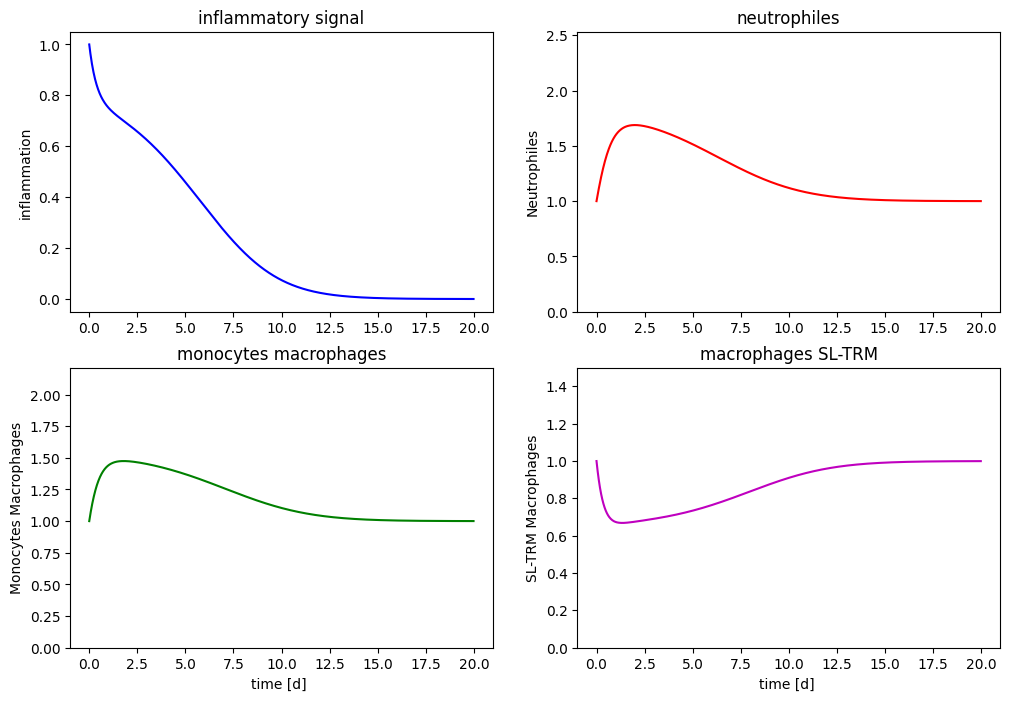

In [5]:
inflam_adim_oliv([1, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=1, duree=20)

## 5. Tester la stabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est stable (par exemple, a/b < 1).

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


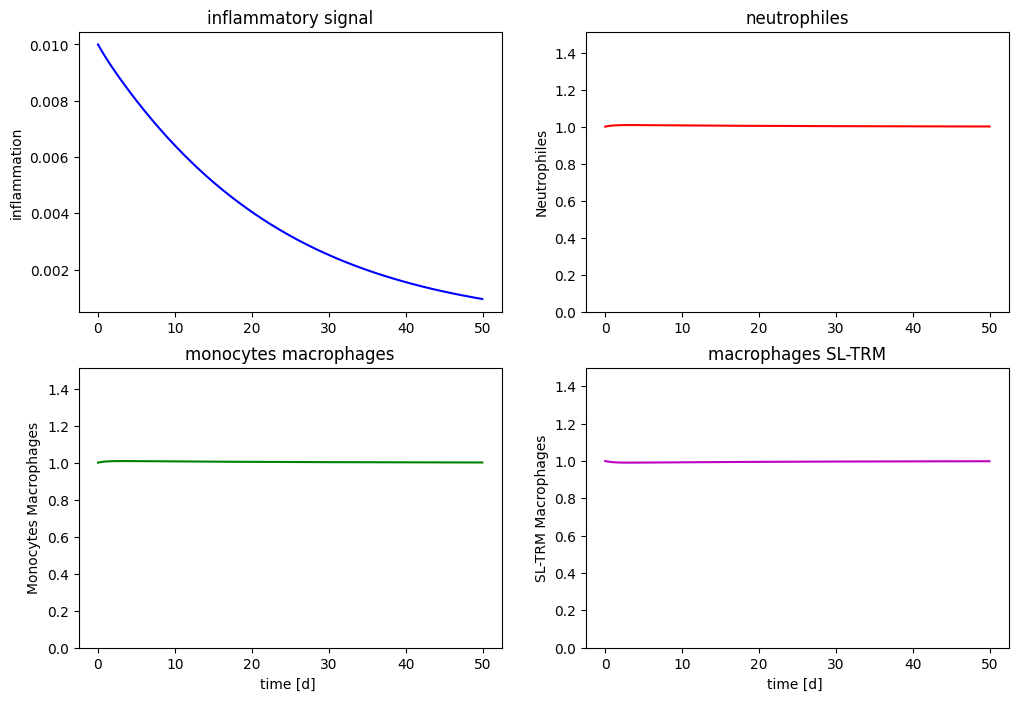

In [6]:
#l'équilibre physiologique est stable si a / b < 1
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.35, b=0.40, duree=50)

## 6. Tester l’instabilité de l’équilibre physiologique

Exemple où l’équilibre physiologique est instable (par exemple, a + b < seuil).

valeurs finales: Signal=0.553, Neutrophiles=1.480, Momac=1.359, SL-TRM=0.730


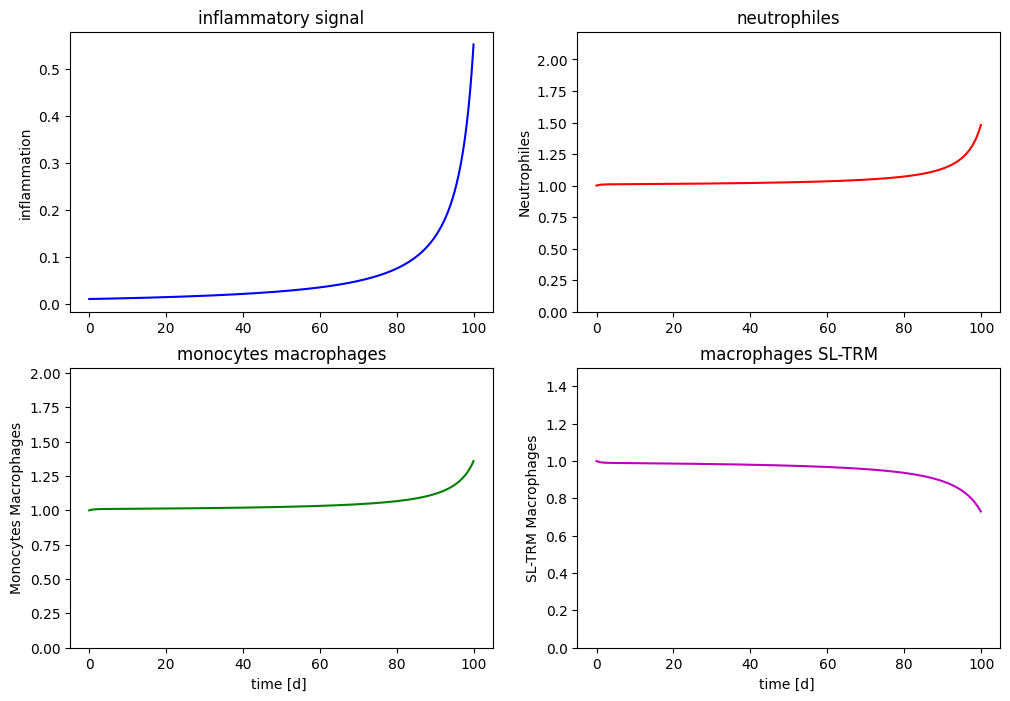

In [7]:
#l'équilibre physiologique est instable si a / b > 1
inflam_adim_oliv([0.01, 1, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=0.31, b=0.30, duree=100)

/tmp/ipykernel_2434383/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


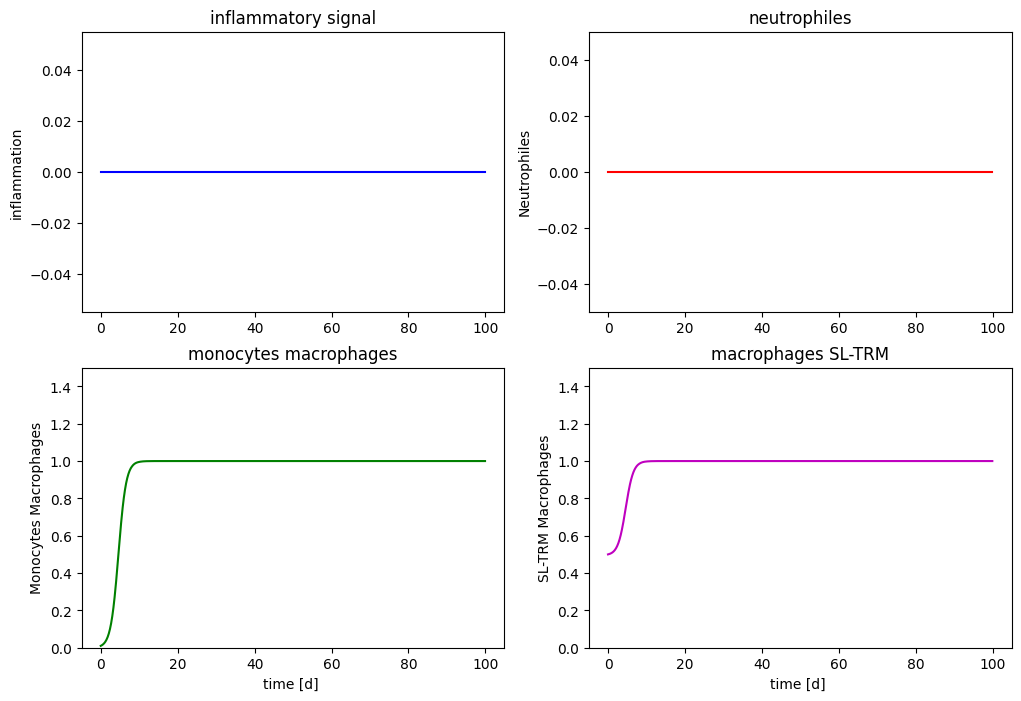

In [8]:
# test 10/10 brain storming pour instabilité des points fixes du type (0,0,0,T) avec T non nul <1
inflam_adim_oliv([0., 0, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


on constate que le système tend vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

/tmp/ipykernel_2434383/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


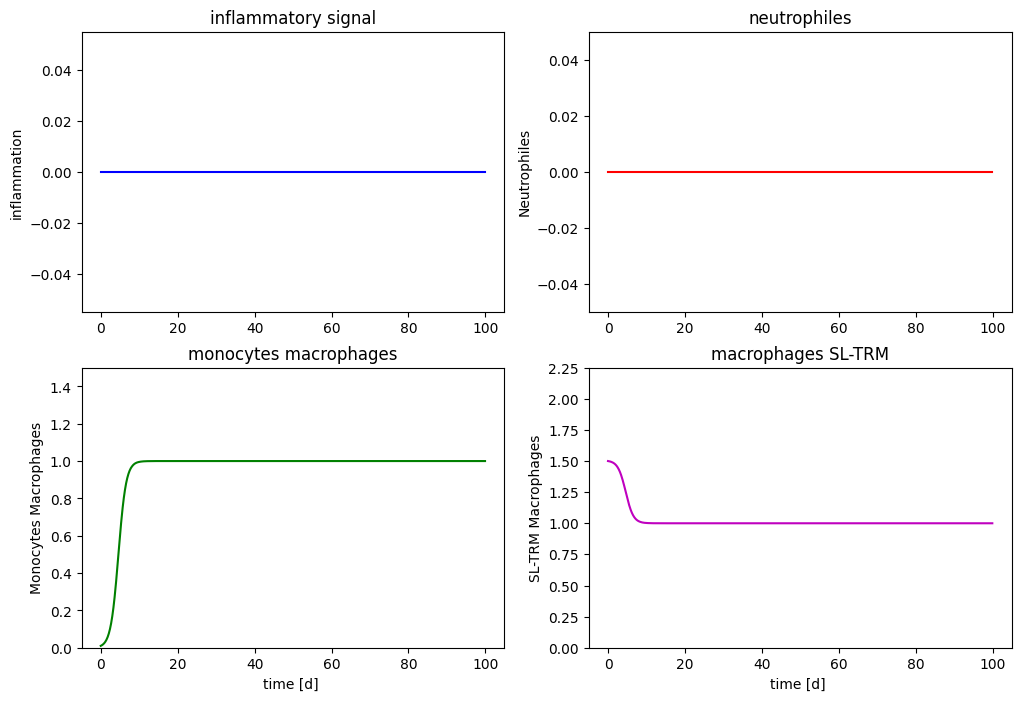

In [9]:
# test pour instabilité des points fixes du type (0,0,0,T) avec T_ini > 1
inflam_adim_oliv([0., 0, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On constate que  le système revient encore vers un autre point fixe $(S,N,M,T)=(0,0,1,1)$

Il semble qu'il y ait une sous-variété invariante $\{0\}\times \{0\}\times \mathbb{R}\times\mathbb{R}$

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


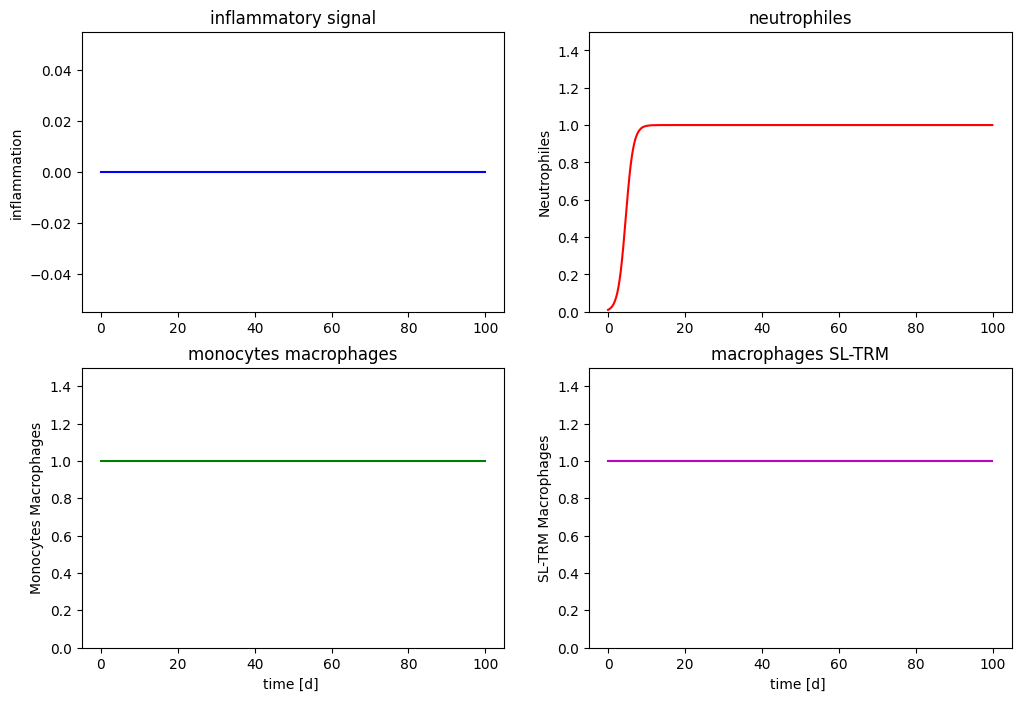

In [10]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0., 0.01, 1, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On voit que le système revient encore vers le point fixe $(S,N,M,T)=(0,1,1,1)$

/tmp/ipykernel_2434383/3660657395.py:22: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(bottom=0, top=ymax)


valeurs finales: Signal=0.000, Neutrophiles=0.000, Momac=1.000, SL-TRM=1.000


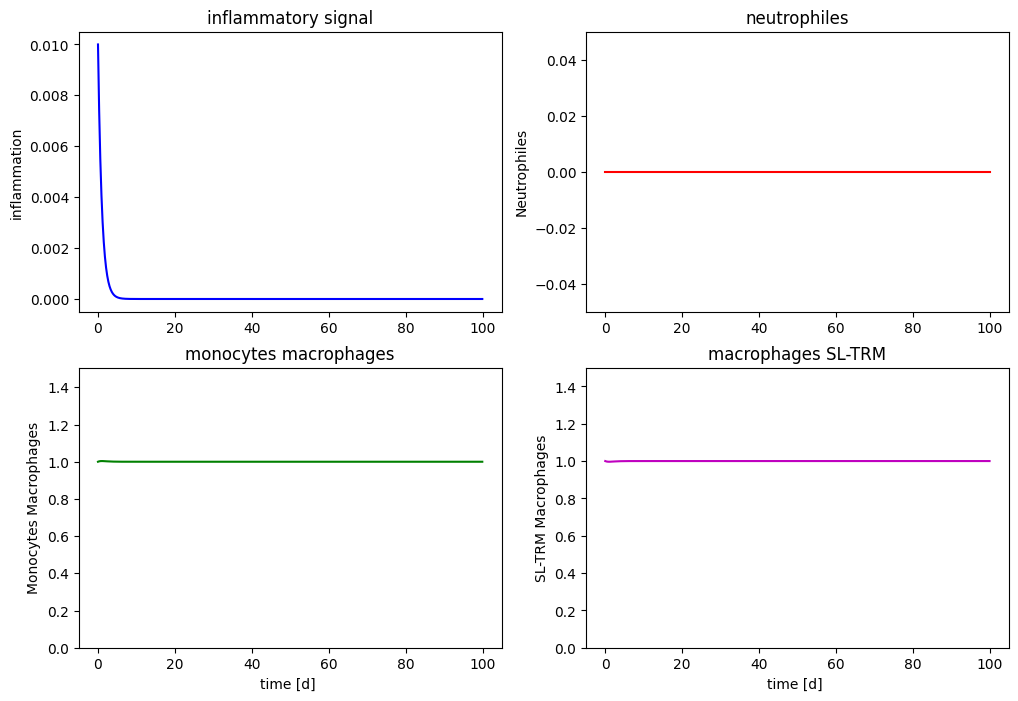

In [11]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,0,1,1)
inflam_adim_oliv([0.01, 0., 1.0, 1],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On constate que ce point $(0,0,1,1)$ est stable pour les pertubations de $S$ et instable pour les perturbations en $N$.

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


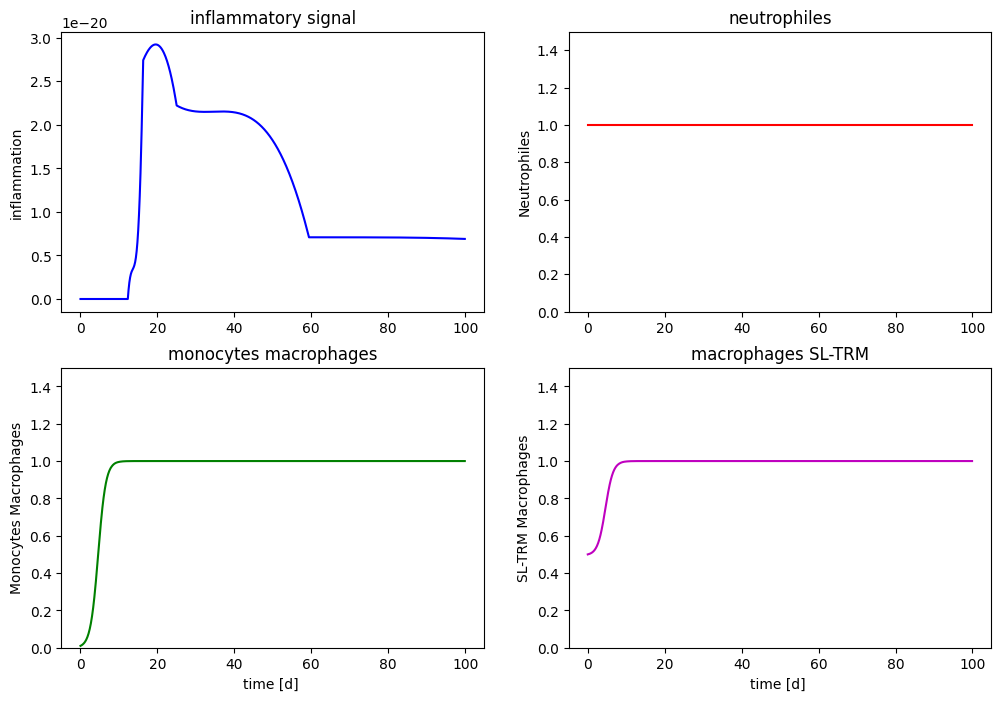

In [12]:
#test 10/10 brain storming pour instabilité des points fixes du type (0,1,0,T) avec T non nul <1
inflam_adim_oliv([0., 1, 0.01, 0.5],
       alpha=1, beta=1, gamma=1,
       delta_N=1, delta_M=1,a=1, b=1, duree=100)


On va vers l'état physiologique. 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


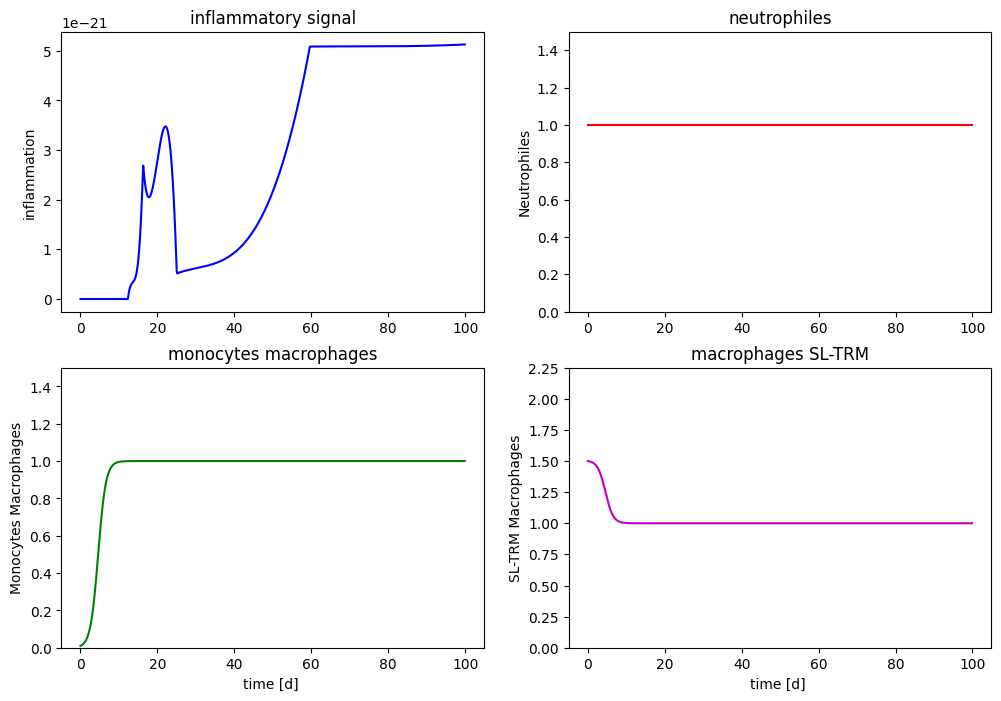

In [13]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini > 1
inflam_adim_oliv([0., 1, 0.01, 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=100)

On remarque un phénomène intéressant: en l'absence de signal immun initial même en présence de Neutrophiles, l'état $(0,1, 0, T)$ évolue vers l'état physiologique.


valeurs finales: Signal=1123.067, Neutrophiles=562.569, Momac=9.574, SL-TRM=0.014


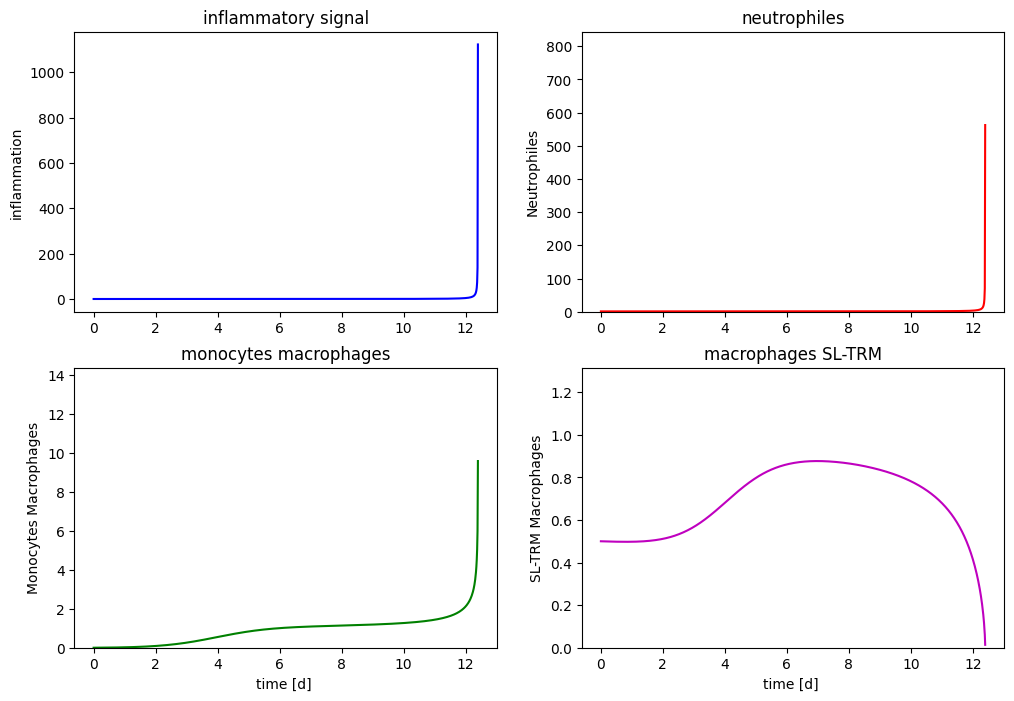

In [14]:
# test pour instabilité des points fixes du type (0,1,0,T) avec T_ini < 1
inflam_adim_oliv([0.01, 1, 0., 0.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=12.5)

On voit un instabilité lorsque le patient a un stock insuffisant de SL-TRM (T) et des neutrophiles.

valeurs finales: Signal=0.001, Neutrophiles=1.001, Momac=1.001, SL-TRM=0.999


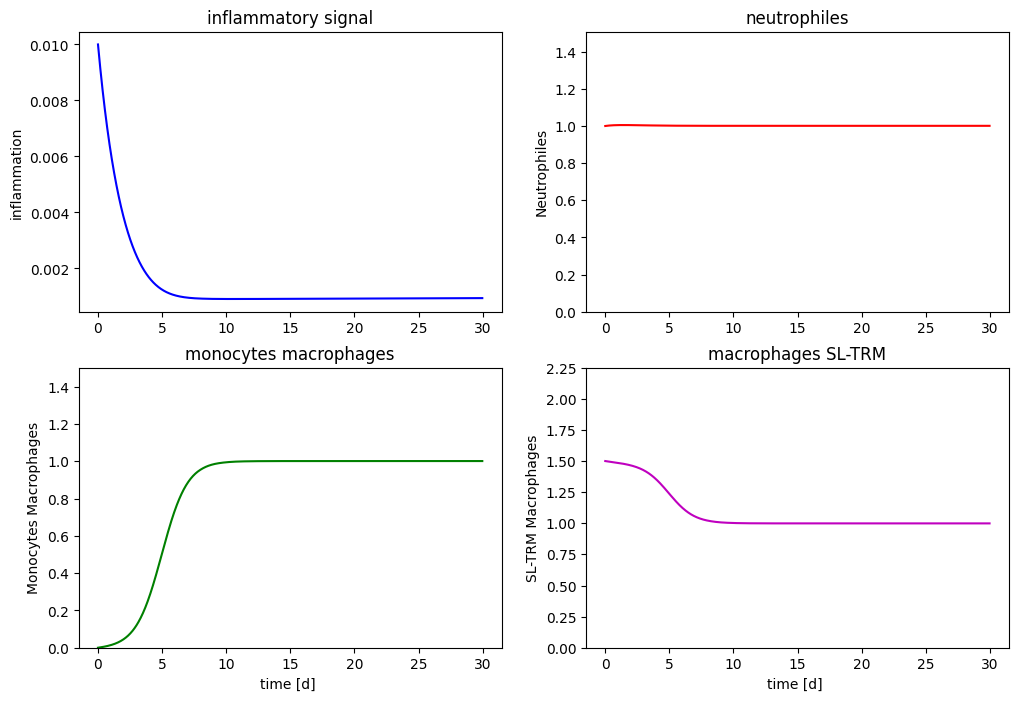

In [15]:
#instabilité des points fixes du type (0,1,0,T) avec T_ini > 1 
inflam_adim_oliv([0.01, 1, 0., 1.5],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=30)


On trouve que la sous-variété $T=1$ est critique pour ce type de point fixe. En effet  lorsque $T>1$ le système revient à l'état physiologique. Alors que pour $T<1$ le système s'emballe. La crise s'amplifie

valeurs finales: Signal=0.004, Neutrophiles=1.015, Momac=1.014, SL-TRM=0.987


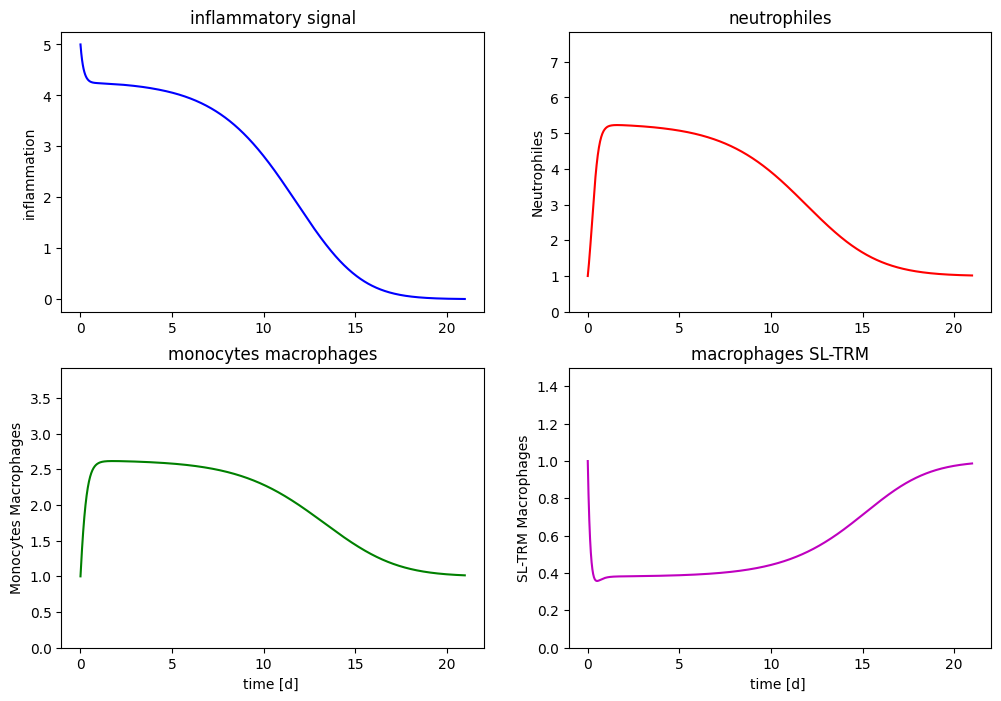

In [16]:
inflam_adim_oliv([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.072, b=1, duree=21)

## 7. Créer une interface interactive pour explorer le modèle

Utilisez les curseurs pour explorer dynamiquement l'effet des paramètres sur le modèle.

In [17]:
# Définition de la fonction interactive
def interactive_inflam_oliv(alpha,beta,gamma,delta_N,delta_M, a, b, duree):
    inflam_adim_oliv([1, 1.00, 1, 1],
           alpha, beta, gamma, delta_N, delta_M, a, b, duree)

# Création des curseurs pour les paramètres
ui = widgets.HBox([
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.01, value=1, description='alpha neutrophiles <-signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='beta Momac <- neutrophiles'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='gamma  SL-TRM <- signal'),
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_N  neutrophiles'),
    ]),
    widgets.VBox([
        widgets.FloatSlider(min=0, max=100, step=0.1, value=1, description='delta_M conversion  Momac -> SL-TRM'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=0.35, description='a feed-back neutrophiles -> signal'),
        widgets.FloatSlider(min=0, max=1, step=0.01, value=1, description='b hold-back SL-TRM -> signal'),
        widgets.IntSlider(min=0, max=20, step=1, value=10, description='durée de la simulation'),
    ])
])

out = widgets.interactive_output(
    interactive_inflam_oliv,
    {
        'alpha': ui.children[0].children[0],
        'beta': ui.children[0].children[1],
        'gamma': ui.children[0].children[2],
        'delta_N': ui.children[0].children[3],
        'delta_M': ui.children[1].children[0],
        'a': ui.children[1].children[1],
        'b': ui.children[1].children[2],
        'duree': ui.children[1].children[3],
    }
)

display(ui, out)

Output()

valeurs finales: Signal=0.149, Neutrophiles=1.151, Momac=1.070, SL-TRM=0.877


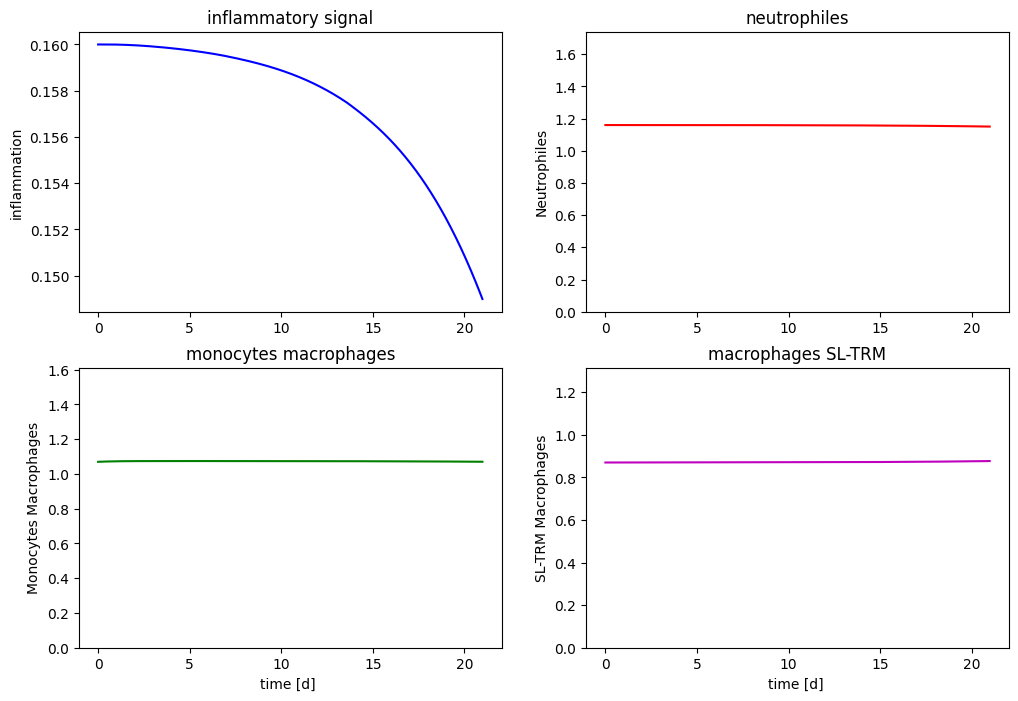

In [18]:
inflam_adim_oliv([0.16, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=21)


Il semble que la trajectoire soit attirée par le point fixe homéostasique $(0,1,1,1)$
Cependant si on double la dose de sérum immun, le scénario est différent:

valeurs finales: Signal=857.395, Neutrophiles=490.962, Momac=5.953, SL-TRM=0.010


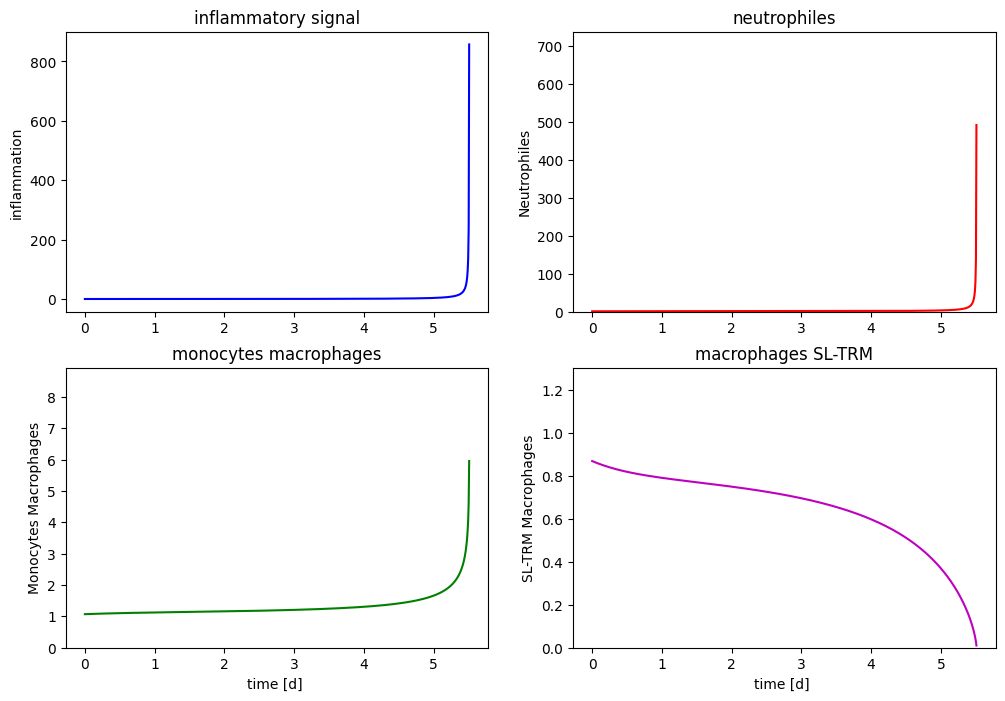

In [19]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=7)


On peut aussi augmenter le pouvoir anti-inflammatoire des macrophages SL-TRM

valeurs finales: Signal=0.070, Neutrophiles=1.093, Momac=1.045, SL-TRM=0.920


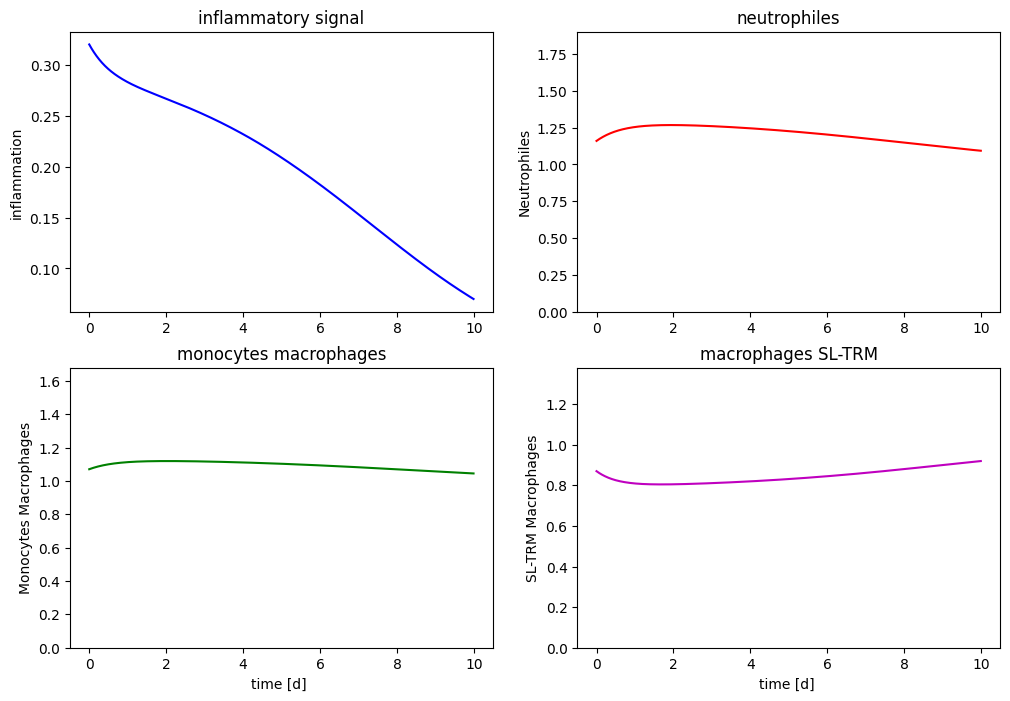

In [20]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1.25, duree=10)


ou diminuer la rétro-action inflammatoire des neutrophiles

valeurs finales: Signal=0.044, Neutrophiles=1.066, Momac=1.032, SL-TRM=0.942


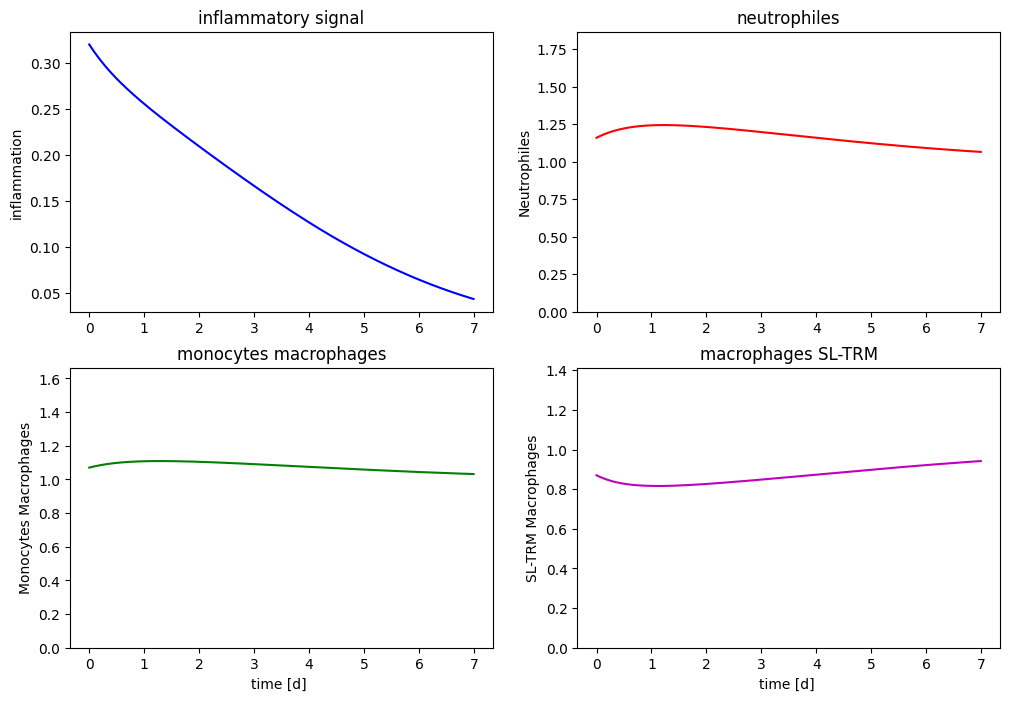

In [21]:
inflam_adim_oliv([0.32, 1.16, 1.07, 0.87],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=7)


valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


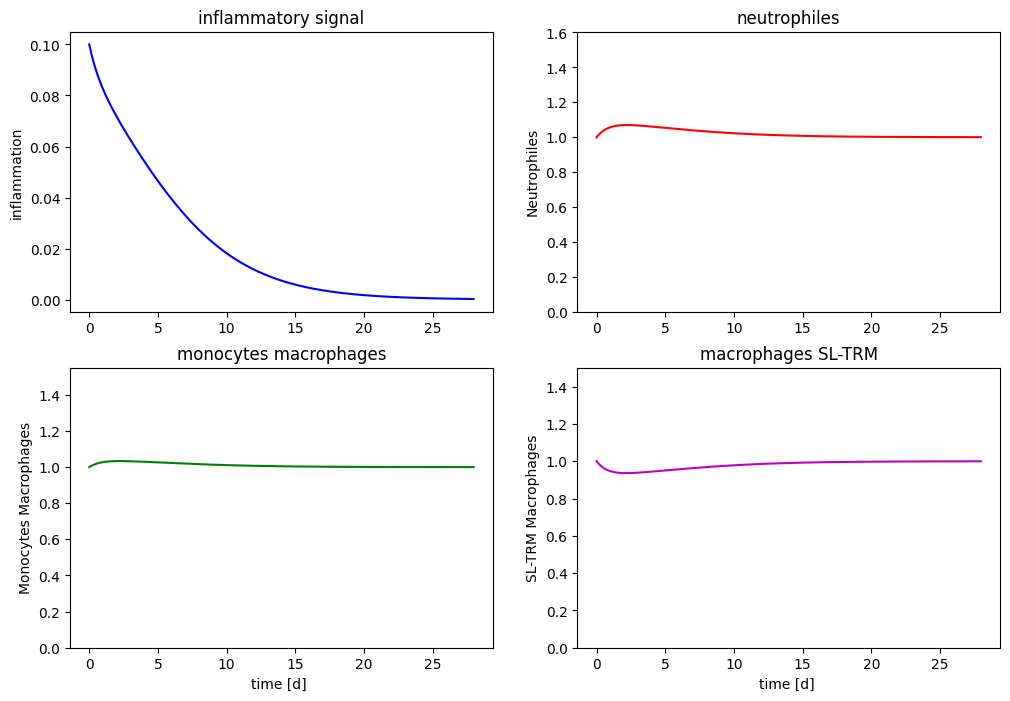

In [22]:
inflam_adim_oliv([0.1, 1-1e-3, 1, 1+1e-3],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.75, b=1, duree=28)

on remarque que la valeur de $a$ est critique pour la résolution de la crise. Si $a$ décroît l'équilibre homéostasique est de plus en plus attractif.

La question se pose : y a-t-il des points d'équilibres stables avec $S\neq 0$?


Pour résumer si $a>b$ i.e. $A>1$ il y a un seul point d'equilibre, c'est l'état homéostasique mais il est instable

valeurs finales: Signal=2.961, Neutrophiles=2.613, Momac=1.498, SL-TRM=0.439


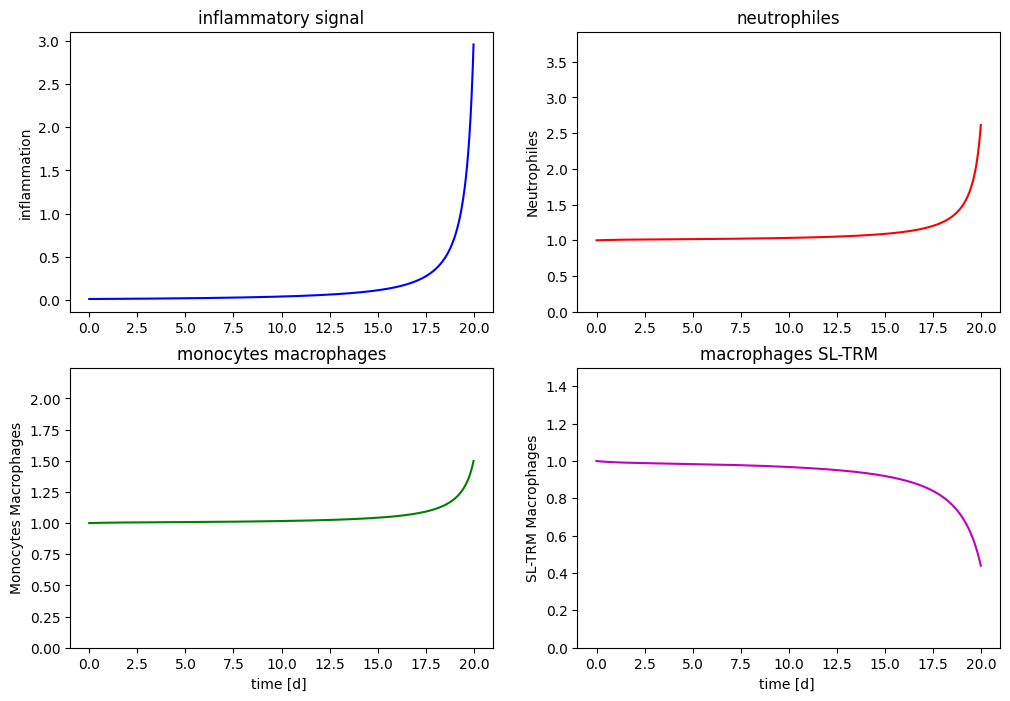

In [23]:
inflam_adim_oliv([0.01, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=1.1, b=1, duree=20)

Pour $a<b$ i.e. pour $A<1$ il y a deux équilibres, l'équilibre homeostasique qui est **stable** et un autre équilibre maladie chronique avec $S\neq 0$ qui est instable. Plus $a/b$ est petit plus le bassin d'attraction de l'équilibre homéostasique est grand

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


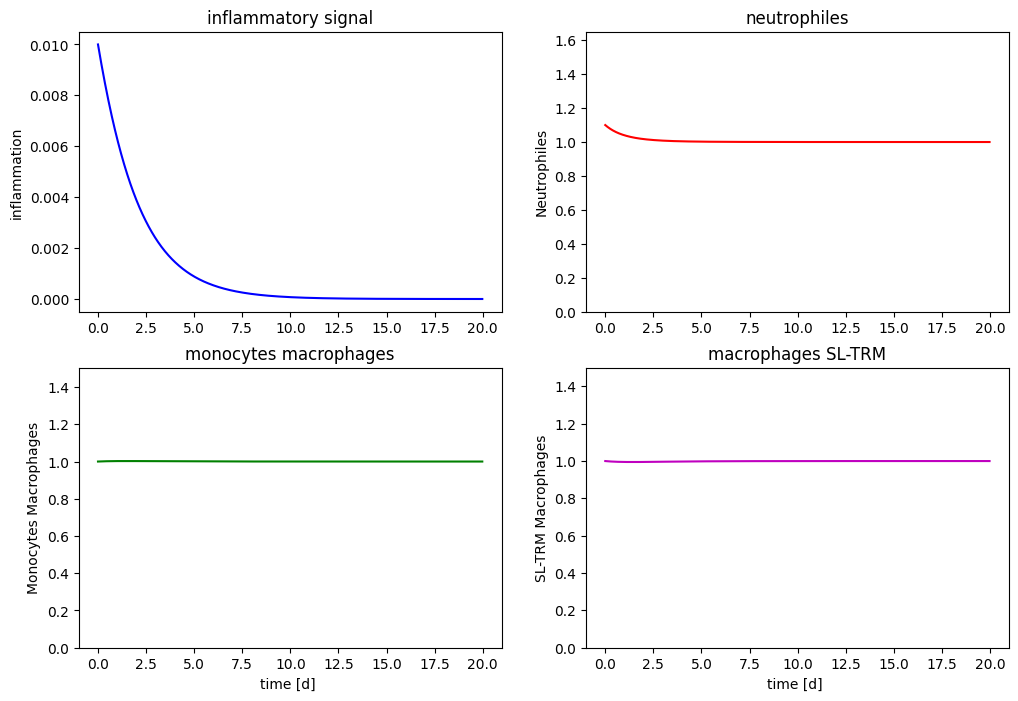

In [24]:
inflam_adim_oliv([0.01, 1.1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


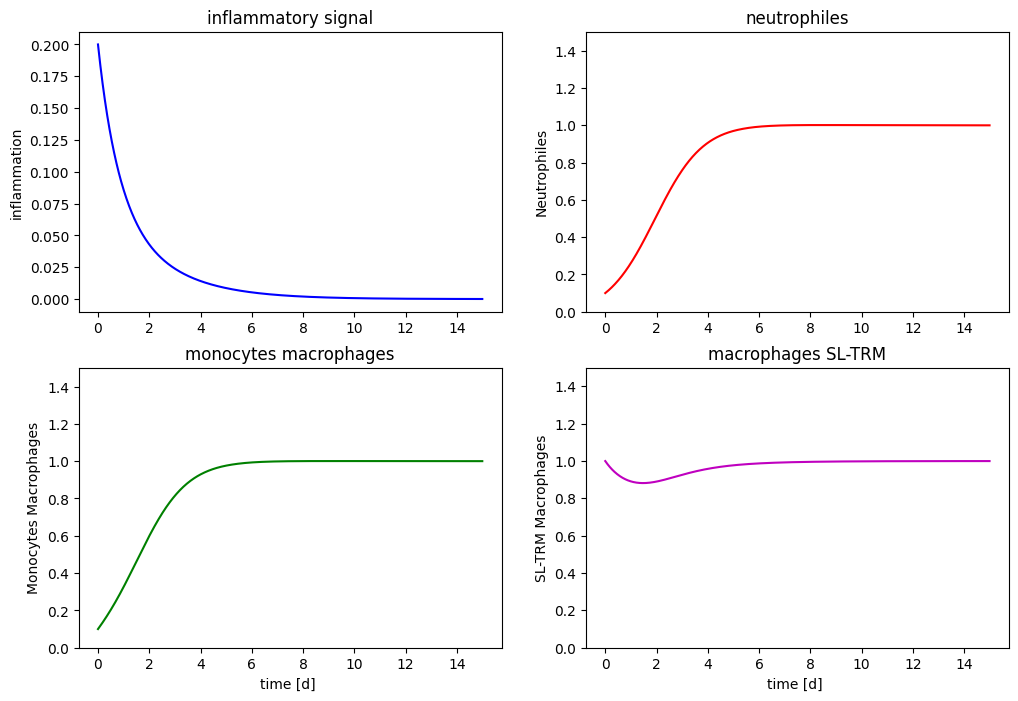

In [25]:
inflam_adim_oliv([0.2, 0.1, 0.1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.5, b=1, duree=15)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


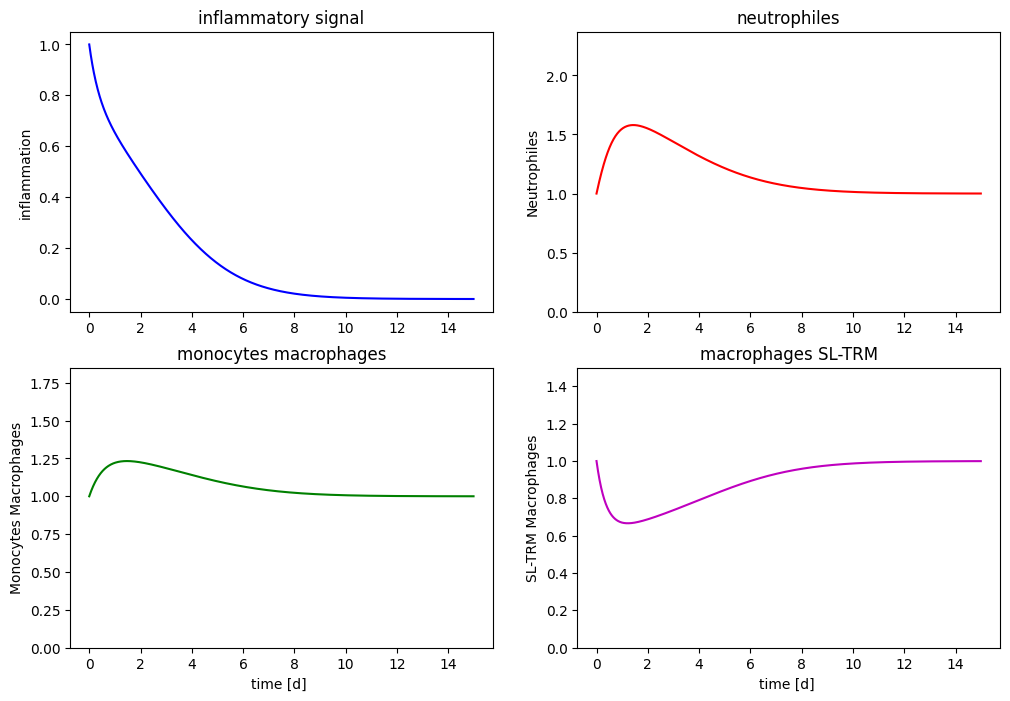

In [26]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.25, b=1, duree=15)

Le cas $a=b$ i.e. $A=1$ est critique. Il y a un seul équilibre, l'équilibre homéostasique mais il est **instable**

valeurs finales: Signal=0.987, Neutrophiles=1.647, Momac=1.253, SL-TRM=0.640


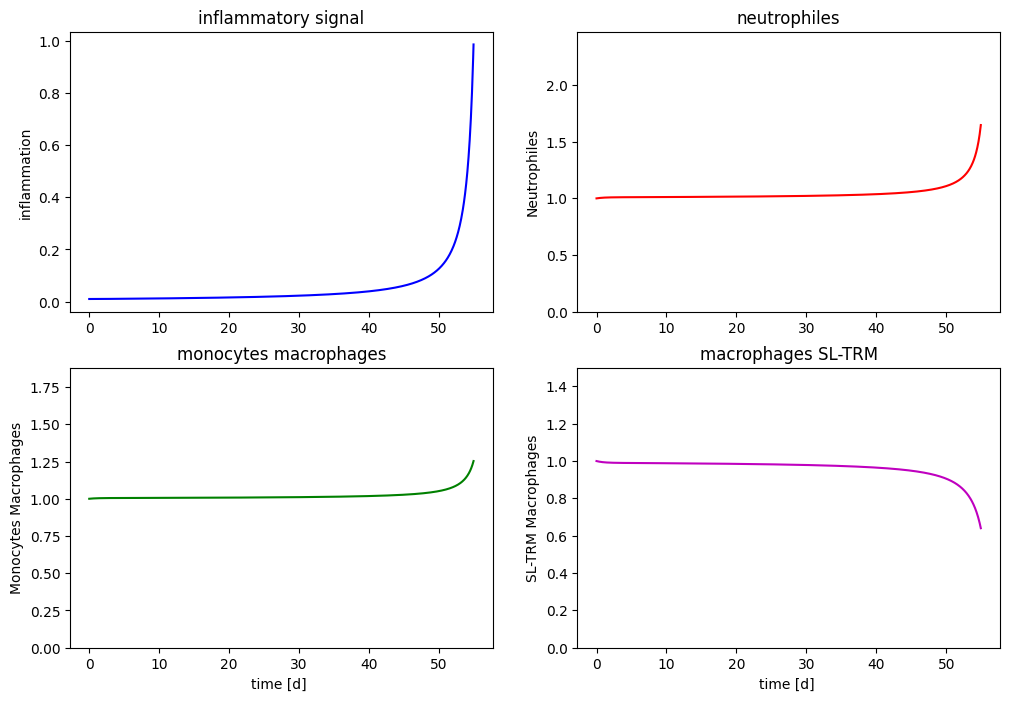

In [27]:
inflam_adim_oliv([0.01, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=1, b=1, duree=55)

valeurs finales: Signal=0.058, Neutrophiles=1.058, Momac=1.028, SL-TRM=0.946


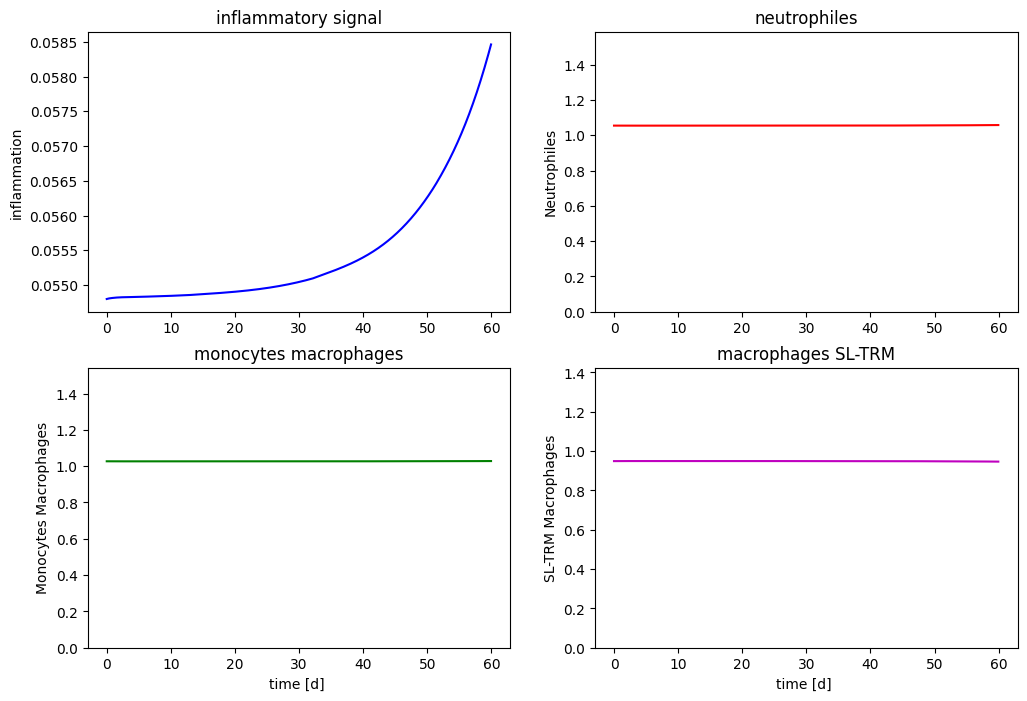

In [28]:
inflam_adim_oliv([0.0548, 1.055, 1.027, 0.949],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.9, b=1, duree=60)

valeurs finales: Signal=243.417, Neutrophiles=153.180, Momac=4.946, SL-TRM=0.027


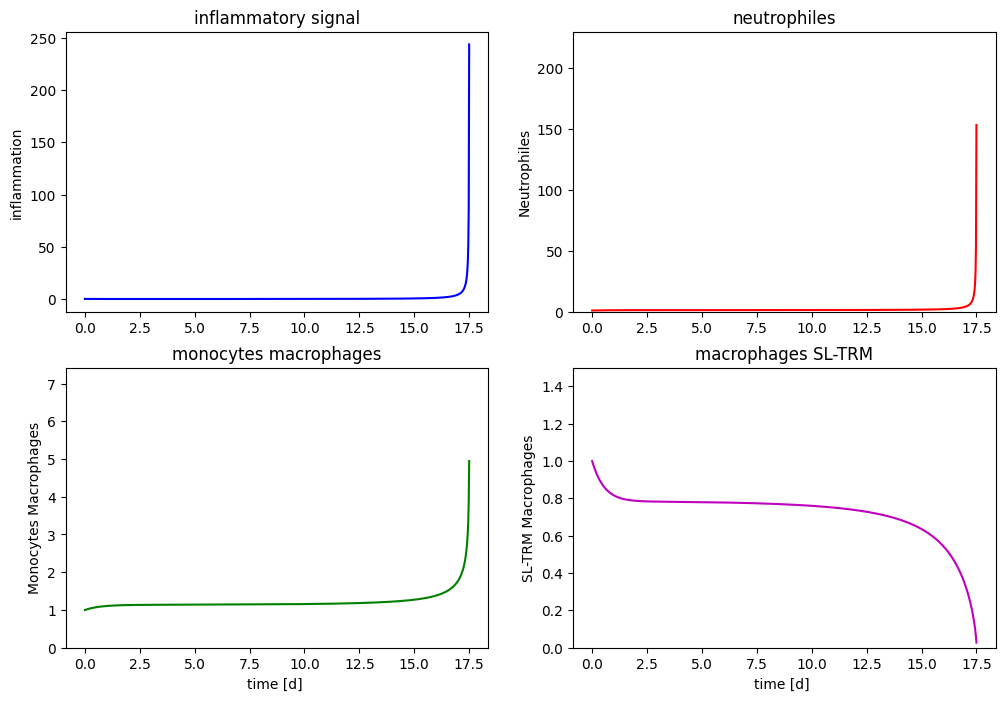

In [29]:
inflam_adim_oliv([0.4, 1, 1, 1],
    alpha=1, beta=0.5, gamma=1,
    delta_N=1, delta_M=1,a=0.6, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


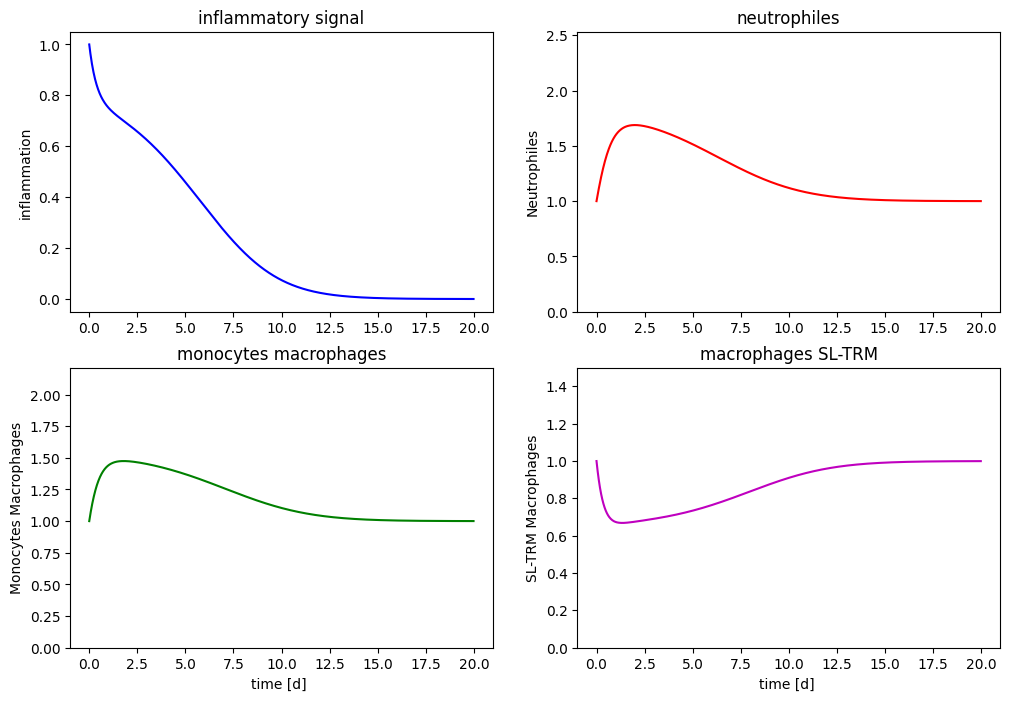

In [30]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.35, b=1, duree=20) 
 

valeurs finales: Signal=1093.401, Neutrophiles=793.340, Momac=13.215, SL-TRM=0.015


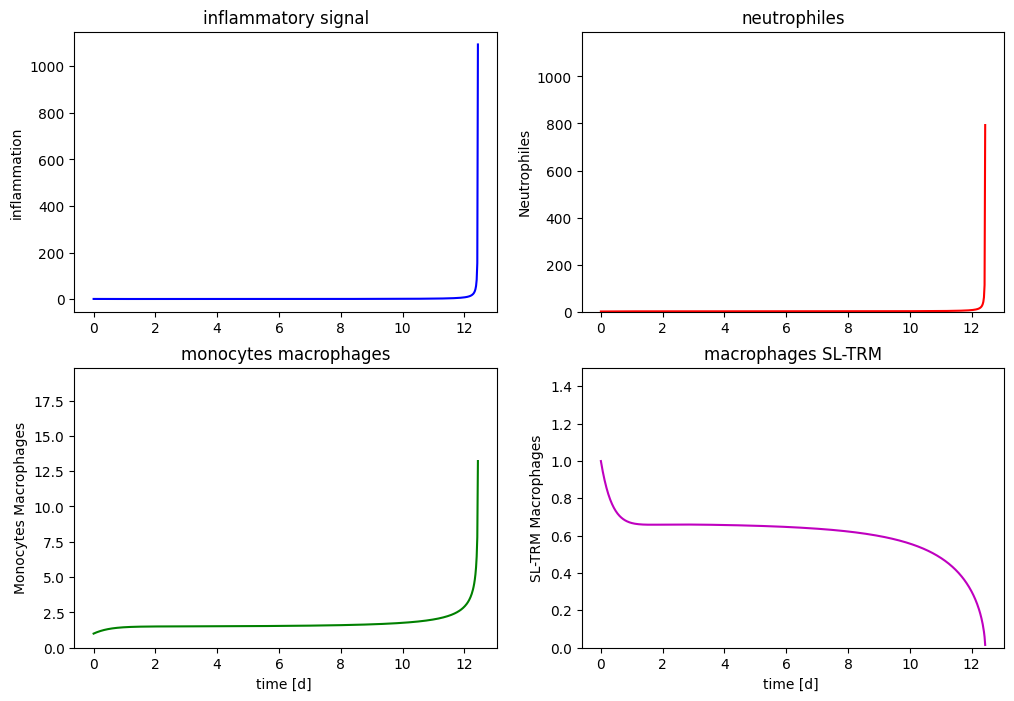

In [31]:
inflam_adim_oliv([1, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


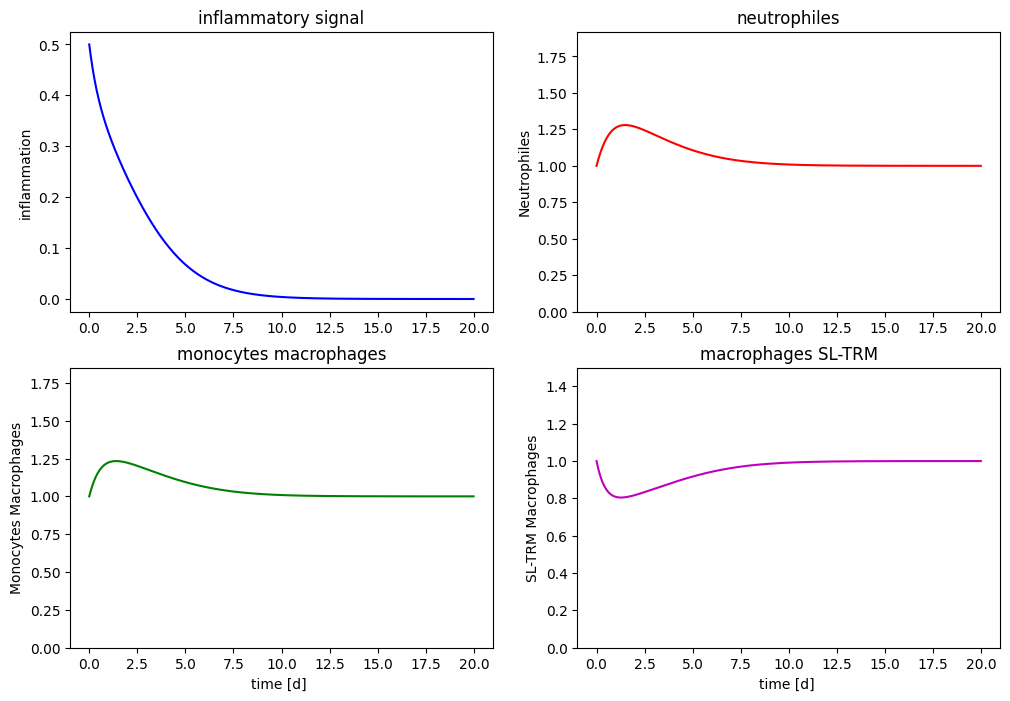

In [32]:
inflam_adim_oliv([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


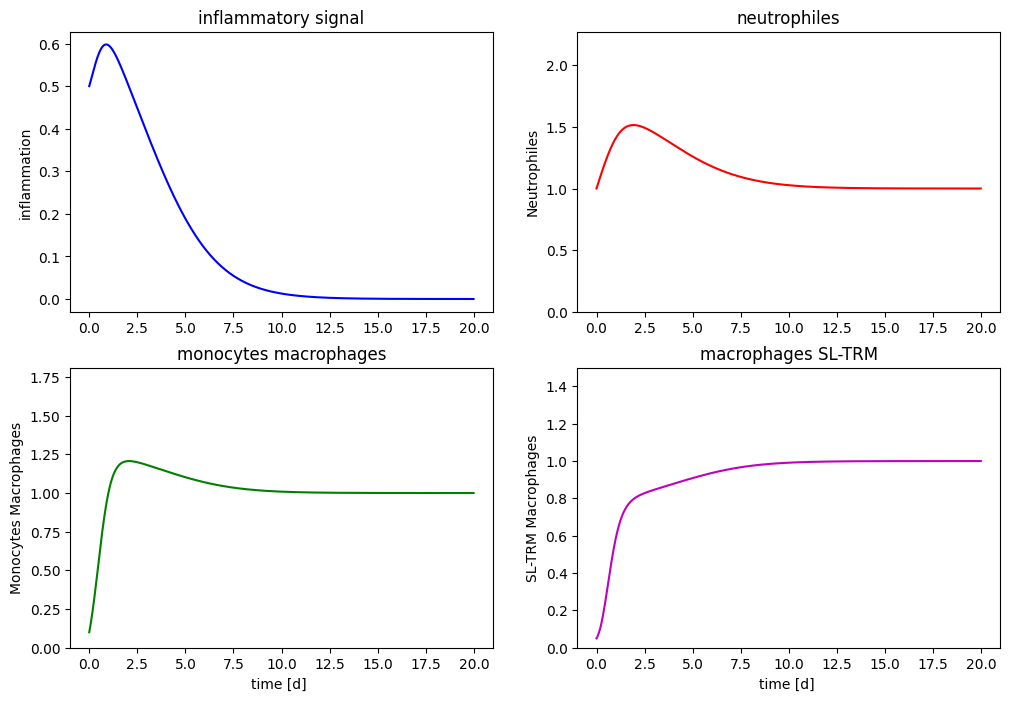

In [33]:
inflam_adim_oliv([0.5, 1, 0.1, 0.05],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=2,a=0.38, b=1, duree=20) 
 

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


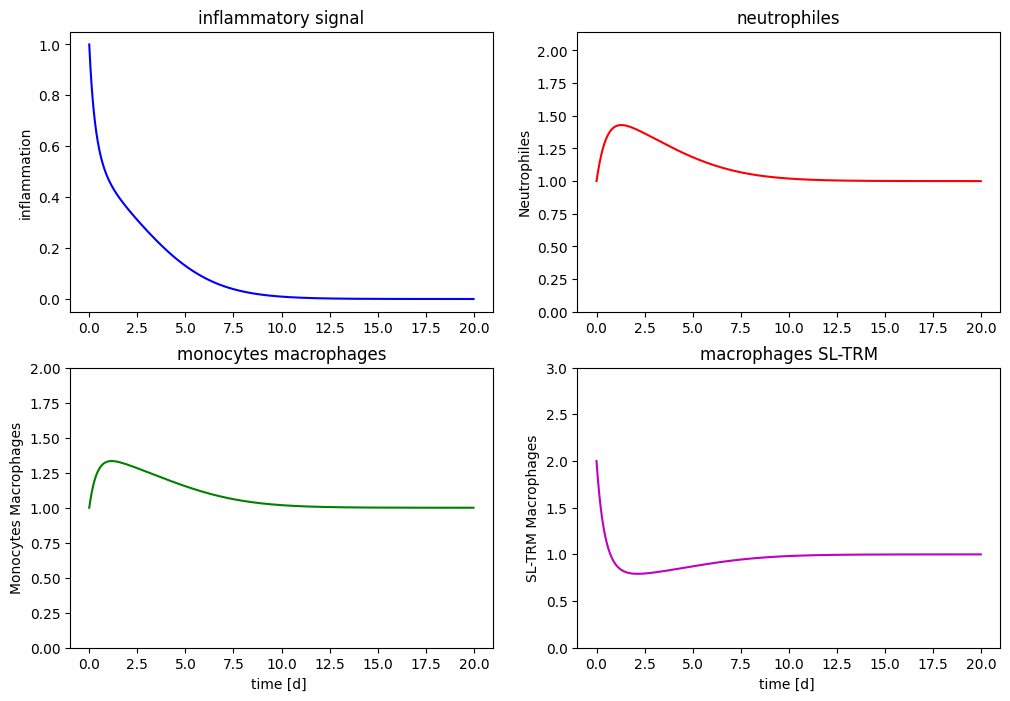

In [34]:
inflam_adim_oliv([1, 1, 1, 2],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.38, b=1, duree=20) 
 

on remarque que si on augmente la population initiale de macrophages SL-TRM le patient triomphe de l'inflammation

Tracé du ratio pro/anti_inflammatoire = N+M/T
(idee de Gabriel Courties)

In [35]:
def inflam_adim_gab(y0, alpha, beta, gamma, delta_N, delta_M, a, b, duree):

    # Résolution des équations différentielles du modèle de la réponse immunitaire
    # le système est raide, on utilise la méthode BDF
    sol = solve_ivp(system_adim_oliv, [0, duree], y0, 'Radau',t_eval=np.arange(0,duree,duree/1000), dense_output=False,
                    args=(alpha, beta, gamma, delta_N, delta_M, a, b))
    S,N,M,T = sol.y
    t=sol.t
    # Traçage des résultats
    plt.figure(figsize=(12, 8))

    plt.subplot(231)
    plt.plot(t, S, 'b', label='inflammation')
    plt.ylabel('inflammation')
    plt.title('inflammatory signal')

    plt.subplot(232)
    plt.plot(t, N, 'r', label='Neutrophiles')
    plt.ylabel('Neutrophiles')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(N)
    plt.ylim(bottom=0, top=ymax)
    plt.title('neutrophiles')

    plt.subplot(233)
    plt.plot(t,M, 'g')
    plt.xlabel('time [d] ')
    plt.ylabel('Monocytes Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(M)
    plt.ylim(bottom=0, top=ymax)
    plt.title('monocytes macrophages')

    plt.subplot(234)
    plt.plot(t,T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('SL-TRM Macrophages')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max(T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('macrophages SL-TRM')

    plt.subplot(235)
    plt.plot(t,(N+M)/T, 'm')
    plt.xlabel('time [d] ')
    plt.ylabel('ratio pro vs anti inflammatory')
    plt.ticklabel_format(style='plain', axis='y')
    ymax = 1.5 * np.max((N+M)/T)
    plt.ylim(bottom=0, top=ymax )
    plt.title('ratio pro vs anti inflammatory')

    plt.subplot(236)
    plt.plot(N+M,T, 'm')
    plt.xlabel('N+M pro-inflammatory')
    plt.ylabel('T anti-inflammatory')
    plt.ticklabel_format(style='plain', axis='y')
    ymin = 0.9 * np.min(T)
    ymax = 1.1 * np.max(T)
    plt.ylim(bottom=ymin, top=ymax )
    plt.title('phase plane immune signal   vs ration pro vs anti inflammatory')

    #plt.subplot(325)
    #plt.plot(M,T, 'm')
    #plt.xlabel('Momac')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.3, 0.01, 'Plan de phase entre Momac et SL-TRM ', ha='center', fontsize=12)

    #plt.subplot(326)
    #plt.plot(S,T, 'm')
    #plt.xlabel('signal inflammatoire')
    #plt.ylabel('SL-TRM Macrophages')
    #plt.ticklabel_format(style='plain', axis='y')
    #ymax = 1.5 * np.max(T)
    #plt.ylim(bottom=0, top=ymax)
    #plt.figtext(0.7, 0.01, 'Plan de phase entre inflammation et SL-TRM ', ha='center', fontsize=12)

    print('valeurs finales:',f"Signal={S[-1]:.3f}, Neutrophiles={N[-1]:.3f}, Momac={M[-1]:.3f}, SL-TRM={T[-1]:.3f}")
    plt.show()
    return

valeurs finales: Signal=0.042, Neutrophiles=1.060, Momac=1.055, SL-TRM=0.949


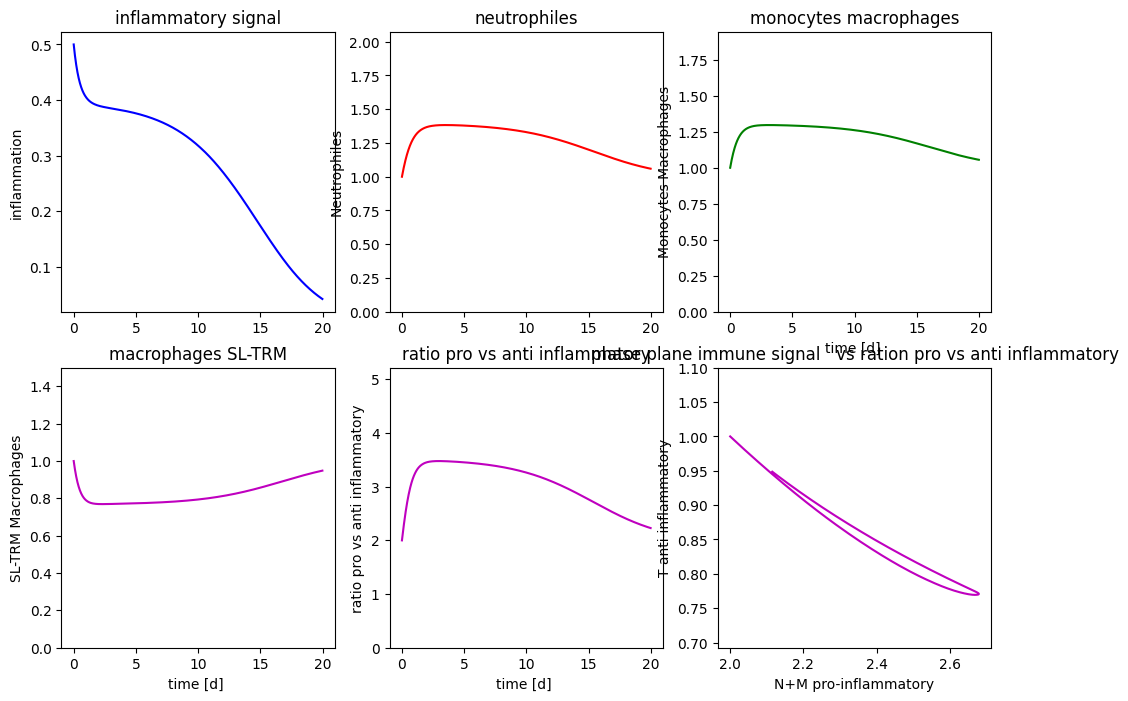

In [36]:
inflam_adim_gab([0.5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.55, b=1, duree=20)

valeurs finales: Signal=0.000, Neutrophiles=1.000, Momac=1.000, SL-TRM=1.000


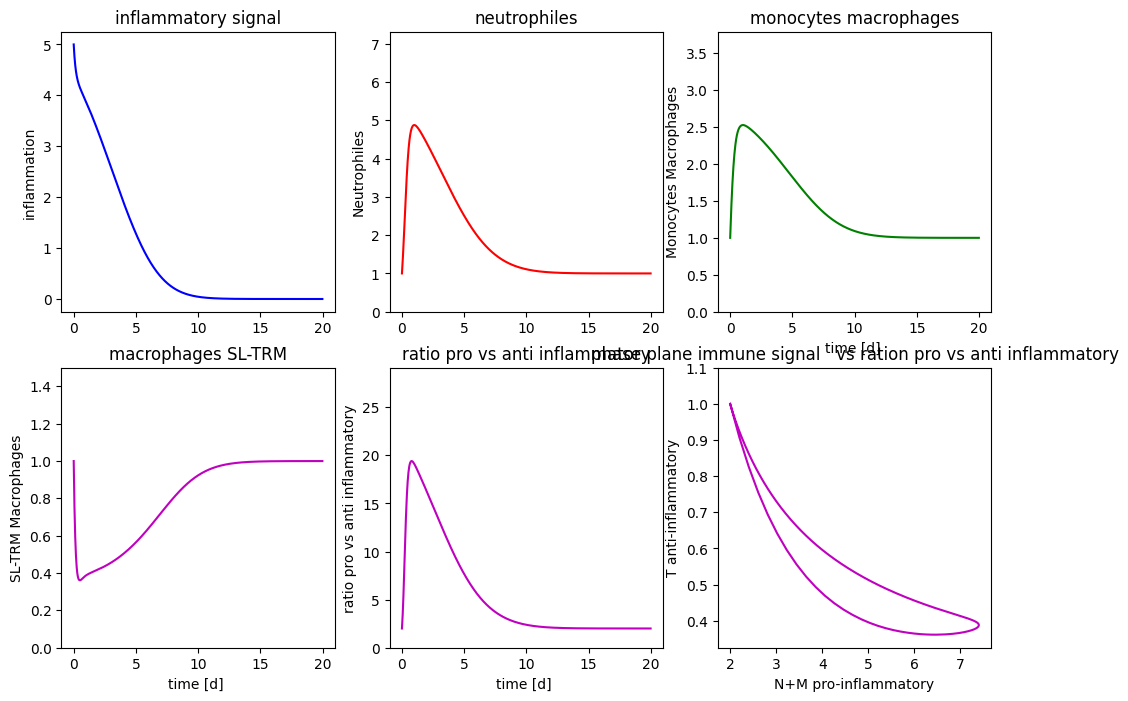

In [37]:
inflam_adim_gab([5, 1, 1, 1],
    alpha=1, beta=1, gamma=1,
    delta_N=1, delta_M=1,a=0.05, b=1, duree=20)

In [38]:
params=np.array([1, 1, 1, 1, 1, 0.35, 1])

### Comment ajuster les 7 paramètres du modèle?
je demande à l'IA...

SYNTHETIC DATA FOR TESTING

True parameters: a=0.400, b=1.000, alpha=1.000
Measurement times: [ 0  2  4  6  8 10 12 14]
Measurement noise: 2.0%

METHOD 1: LEAST SQUARES OPTIMIZATION

Optimization success: True
Fitted parameters: a=0.2447, b=0.8065
Residual norm: 0.076046


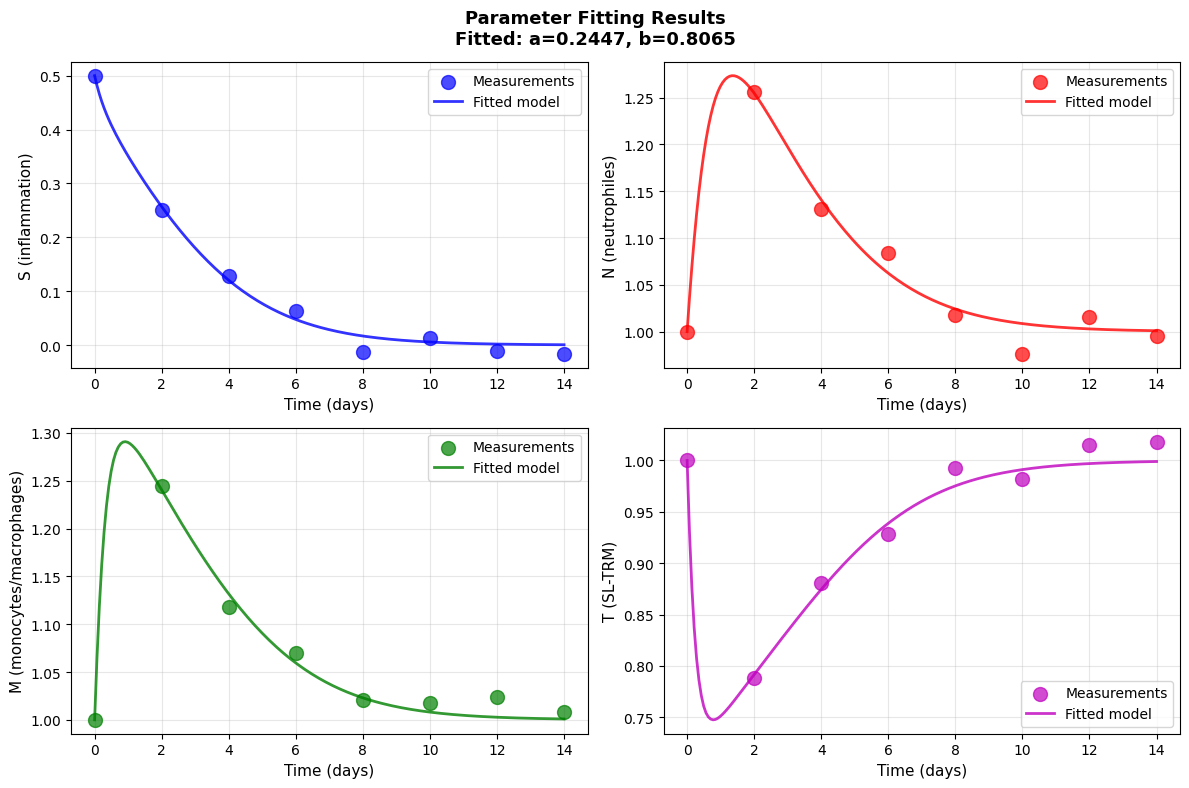


 3-PARAMETER LEAST-SQUARES FIT

Optimization success: True
Fitted parameters: alpha=0.9001, a=0.4557, b=1.0753

FULL 7-PARAMETER LEAST-SQUARES FIT
Optimization success: True
Residual norm: 0.076046
Fitted parameters:
  a=0.2447, b=0.8065, alpha=1.0761, beta=2.0220,
  gamma=2.2574, delta_N=1.2381, delta_M=1.9423


In [40]:
from scipy.optimize import least_squares, differential_evolution

from scipy.integrate import solve_ivp
import numpy as np

# Parameter estimation for the inflammatory model using in vivo measurements
# Several methods are available depending on your data characteristics

import matplotlib.pyplot as plt

# ============================================================================
# METHOD 1: Least Squares Optimization (best for small perturbations)
# ============================================================================
# Fit all 7 parameters with order: [a, b, alpha, beta, gamma, delta_N, delta_M]
def objective_least_squares(params_to_fit, t_data, y_data, _fixed_params_unused=None):
    a_fit, b_fit, alpha_fit, beta_fit, gamma_fit, delta_N_fit, delta_M_fit = params_to_fit
    y0 = y_data[0]

    try:
        sol = solve_ivp(
           system_adim_oliv,
            [t_data[0], t_data[-1]],
            y0,
            args=(alpha_fit, beta_fit, gamma_fit, delta_N_fit, delta_M_fit, a_fit, b_fit),
            t_eval=t_data,
            method="Radau",
        )

        if not sol.success:
            return np.full(y_data.size, 1e10)
        return (sol.y.T - y_data).ravel()
    except Exception:
        return np.full(y_data.size, 1e10)
    
def fit_parameters_least_squares(t_data, y_data, fixed_params, initial_guess, bounds=None):
    if bounds is None:
        bounds = (np.zeros(7), np.array([2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0], dtype=float))

    result = least_squares(
        objective_least_squares,
        initial_guess,
        args=(t_data, y_data, fixed_params),
        bounds=bounds,
        max_nfev=20000,
    )

    # Keep downstream plotting code compatible (it expects fixed_params_1 = 5-tuple)
    a_fit, b_fit, alpha_fit, beta_fit, gamma_fit, delta_N_fit, delta_M_fit = result.x
    globals()["fixed_params_1"] = (alpha_fit, beta_fit, gamma_fit, delta_N_fit, delta_M_fit)
    return result

# ============================================================================
# METHOD 2: Global Optimization with Differential Evolution
# ============================================================================

# def objective_global(params_to_fit, t_data, y_data, fixed_params, weights=None):
#     """
#     Objective function for global optimization (e.g., sum of squared errors).
#     """
#     alpha, beta, gamma, delta_N, delta_M, a, b = fixed_params
#     alpha_fit, a_fit, b_fit = params_to_fit
    
#     y0 = y_data[0]
    
#     try:
#         sol = solve_ivp(
#             system_adim_oliv,
#             [t_data[0], t_data[-1]],
#             y0,
#             args=(alpha_fit, beta, gamma, delta_N, delta_M, a_fit, b_fit),
#             t_eval=t_data,
#             method='Radau'
#         )
        
#         if not sol.success:
#             return 1e10
        
#         # Weighted sum of squared errors
#         error = np.sum((sol.y.T - y_data)**2)
        
#         if weights is not None:
#             error = np.sum(weights * (sol.y.T - y_data)**2)
        
#         return error
    
#     except:
#         return 1e10


# def fit_parameters_global(t_data, y_data, fixed_params, bounds):
#     """
#     Fit parameters using global optimization (Differential Evolution).
#     bounds: list of (min, max) tuples for each parameter
#     """
#     result = differential_evolution(
#         objective_global,
#         bounds,
#         args=(t_data, y_data, fixed_params),
#         seed=42,
#         maxiter=1000,
#         workers=1
#     )
    
    return result


# ============================================================================
# METHOD 3: Maximum Likelihood Estimation (for measurement errors)
# ============================================================================

def objective_mle(params_to_fit, t_data, y_data, fixed_params, sigma=0.1):
    """
    Maximum Likelihood Estimation assuming Gaussian measurement noise.
    sigma: measurement standard deviation (assumed same for all measurements)
    """
    alpha, beta, gamma, delta_N, delta_M, a, b = fixed_params
    alpha_fit, a_fit, b_fit = params_to_fit
    
    y0 = y_data[0]
    
    try:
        sol = solve_ivp(
            system_adim_oliv,
            [t_data[0], t_data[-1]],
            y0,
            args=(alpha_fit, beta, gamma, delta_N, delta_M, a_fit, b_fit),
            t_eval=t_data,
            method='Radau'
        )
        
        if not sol.success:
            return 1e10
        
        # Negative log likelihood (for minimization)
        residuals = sol.y.T - y_data
        nll = -np.sum(-0.5 * (residuals / sigma)**2)  # Gaussian likelihood
        
        return nll
    
    except:
        return 1e10


# ============================================================================
# EXAMPLE USAGE: Synthetic data with added noise
# ============================================================================

# Simulate synthetic measurements
np.random.seed(42)
t_measurements = np.array([0, 2, 4, 6, 8, 10, 12, 14])  # measurement times (days)
y0_true = np.array([0.5, 1.0, 1.0, 1.0])
params_true = (1.0, 1.0, 1.0, 1.0, 1.0, 0.4, 1.0)

# Generate synthetic data
sol_true = solve_ivp(
    system_adim_oliv,
    [t_measurements[0], t_measurements[-1]],
    y0_true,
    args=params_true,
    t_eval=t_measurements,
    method='Radau'
)

# Add measurement noise (2% standard deviation)
noise_level = 0.02
y_measured = sol_true.y.T + np.random.normal(0, noise_level, sol_true.y.T.shape)
y_measured = np.clip(y_measured, 1e-3, None)  # Ensure positive values
# Rebuild measurements so the initial condition stays exact (no noise at t_measurements[0])
y_measured = sol_true.y.T.copy()

# Add noise only for t_measurements[1:]
y_measured[1:] += np.random.normal(0, noise_level, size=y_measured[1:].shape)

print("=" * 70)
print("SYNTHETIC DATA FOR TESTING")
print("=" * 70)
print(f"\nTrue parameters: a={params_true[5]:.3f}, b={params_true[6]:.3f}, alpha={params_true[0]:.3f}")
print(f"Measurement times: {t_measurements}")
print(f"Measurement noise: {noise_level*100:.1f}%")

# ============================================================================
# TEST METHOD 1: Least Squares
# ============================================================================

print("\n" + "=" * 70)
print("METHOD 1: LEAST SQUARES OPTIMIZATION")
print("=" * 70)

fixed_params_1 = (1.0, 1.0, 1.0, 1.0, 1.0)  # alpha, beta, gamma, delta_N, delta_M
initial_guess_1 = [0.35, 1.0]  # Initial guess for [a, b]

# Initialize for 7-parameter fit from existing `params = (alpha, beta, gamma, delta_N, delta_M, a, b)`
fixed_params_1 = (params[0], params[1], params[2], params[3], params[4])
initial_guess_1 = np.array([params[5], params[6], params[0], params[1], params[2], params[3], params[4]], dtype=float)
result_ls = fit_parameters_least_squares(
    t_measurements, 
    y_measured, 
    fixed_params_1,
    initial_guess_1
)

print(f"\nOptimization success: {result_ls.success}")
print(f"Fitted parameters: a={result_ls.x[0]:.4f}, b={result_ls.x[1]:.4f}")
print(f"Residual norm: {np.linalg.norm(result_ls.fun):.6f}")

# ============================================================================
# VISUALIZATION: Compare model fit with measurements
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Rerun solution with fitted parameters for plotting
sol_fitted = solve_ivp(
    system_adim_oliv,
    [t_measurements[0], t_measurements[-1]],
    y_measured[0],
    args=(fixed_params_1[0], fixed_params_1[1], fixed_params_1[2], 
          fixed_params_1[3], fixed_params_1[4], result_ls.x[0], result_ls.x[1]),
    t_eval=np.linspace(t_measurements[0], t_measurements[-1], 200),
    method='Radau'
)

labels = ['S (inflammation)', 'N (neutrophiles)', 'M (monocytes/macrophages)', 'T (SL-TRM)']
colors = ['b', 'r', 'g', 'm']

for i, (ax, label, color) in enumerate(zip(axes.flat, labels, colors)):
    # Plot measurements
    ax.scatter(t_measurements, y_measured[:, i], color=color, s=100, 
              marker='o', label='Measurements', zorder=5, alpha=0.7)
    
    # Plot fitted model
    ax.plot(sol_fitted.t, sol_fitted.y[i], color=color, linewidth=2, 
           label='Fitted model', alpha=0.8)
    
    ax.set_xlabel('Time (days)', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.suptitle(f'Parameter Fitting Results\nFitted: a={result_ls.x[0]:.4f}, b={result_ls.x[1]:.4f}', 
            fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('parameter_fitting_result.png', dpi=150, bbox_inches='tight')
plt.show()

# Fix: objective_least_squares expects:
# - fixed_params with 7 values: (alpha, beta, gamma, delta_N, delta_M, a, b)
# - params_to_fit with 3 values: (alpha_fit, a_fit, b_fit)

fixed_params_1 = (1.0, 1.0, 1.0, 1.0, 1.0, 0.35, 1.0)
initial_guess_1 = [1.0, 0.35, 1.0]

# 3-parameter fit (alpha, a, b) with 7 fixed baseline params
def objective_least_squares_3(params_to_fit, t_data, y_data, fixed_params):
    alpha_fit, a_fit, b_fit = params_to_fit
    alpha0, beta0, gamma0, delta_N0, delta_M0, _, _ = fixed_params
    #beta0, gamma0, delta_N0, delta_M0 = fixed_params
    y0 = y_data[0]

    try:
        sol = solve_ivp(
            system_adim_oliv,
            [t_data[0], t_data[-1]],
            y0,
            args=(alpha_fit, beta0, gamma0, delta_N0, delta_M0, a_fit, b_fit),
            t_eval=t_data,
            method="Radau",
        )
        if not sol.success:
            return np.full(y_data.size, 1e10)
        return (sol.y.T - y_data).ravel()
    except Exception:
        return np.full(y_data.size, 1e10)

bounds_3 = (
    np.array([0.0, 0.0, 0.0], dtype=float),   # alpha, a, b lower
    np.array([3.0, 2.0, 2.0], dtype=float),   # alpha, a, b upper
)

result_ls = least_squares(
    objective_least_squares_3,
    np.asarray(initial_guess_1, dtype=float),   # must be length 3
    args=(t_measurements, y_measured, fixed_params_1),
    bounds=bounds_3,
    max_nfev=20000,
)
print("\n" + "=" * 70)
print(" 3-PARAMETER LEAST-SQUARES FIT")
print("=" * 70)
print(f"\nOptimization success: {result_ls.success}")
print(f"Fitted parameters: alpha={result_ls.x[0]:.4f}, a={result_ls.x[1]:.4f}, b={result_ls.x[2]:.4f}")
# --- Full 7-parameter fit: [a, b, alpha, beta, gamma, delta_N, delta_M] ---

def objective_least_squares_full(params_to_fit, t_data, y_data):
    a_fit, b_fit, alpha_fit, beta_fit, gamma_fit, delta_N_fit, delta_M_fit = params_to_fit
    y0 = y_data[0]

    try:
        sol = solve_ivp(
            system_adim_oliv,
            [t_data[0], t_data[-1]],
            y0,
            args=(alpha_fit, beta_fit, gamma_fit, delta_N_fit, delta_M_fit, a_fit, b_fit),
            t_eval=t_data,
            method="Radau"
        )
        if not sol.success:
            return np.full(y_data.size, 1e10)
        return (sol.y.T - y_data).ravel()
    except Exception:
        return np.full(y_data.size, 1e10)

# Initial guess from existing `params` = (alpha, beta, gamma, delta_N, delta_M, a, b)
initial_guess_full = np.array([params[5], params[6], params[0], params[1], params[2], params[3], params[4]], dtype=float)

# Positive bounds (adjust if needed)
lower_bounds = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
upper_bounds = np.array([2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0])

result_ls_full = least_squares(
    objective_least_squares_full,
    initial_guess_full,
    args=(t_measurements, y_measured),
    bounds=(lower_bounds, upper_bounds),
    max_nfev=20000
)

print("\n" + "=" * 70)
print("FULL 7-PARAMETER LEAST-SQUARES FIT")
print("=" * 70)
print(f"Optimization success: {result_ls_full.success}")
print(f"Residual norm: {np.linalg.norm(result_ls_full.fun):.6f}")

a_hat, b_hat, alpha_hat, beta_hat, gamma_hat, deltaN_hat, deltaM_hat = result_ls_full.x
print(
    f"Fitted parameters:\n"
    f"  a={a_hat:.4f}, b={b_hat:.4f}, alpha={alpha_hat:.4f}, beta={beta_hat:.4f},\n"
    f"  gamma={gamma_hat:.4f}, delta_N={deltaN_hat:.4f}, delta_M={deltaM_hat:.4f}"
)

# Optional: fitted trajectory for later plotting
sol_fitted_full = solve_ivp(
    system_adim_oliv,
    [t_measurements[0], t_measurements[-1]],
    y_measured[0],
    args=(alpha_hat, beta_hat, gamma_hat, deltaN_hat, deltaM_hat, a_hat, b_hat),
    t_eval=np.linspace(t_measurements[0], t_measurements[-1], 200),
    method="Radau"
)

J'ai demandé à l'IA d'implementer Parameter Estimation with Physics-Informed Neural Networks for ODEs comme sur cet exemple
Parameter Estimation with Physics-Informed Neural Networks for ODEs

Les PINNs constituent une alternative puissante aux méthodes classiques d'optimisation. Contrairement aux approches traditionnelles (moindres carrés, maximum de vraisemblance), les PINNs intègrent directement les équations différentielles comme contraintes dans la fonction de perte du réseau de neurones.

**Avantages des PINNs pour l'estimation de paramètres :**
- Régularisation physique : le modèle reste fidèle à la dynamique même avec peu de données
- Gestion robuste du bruit de mesure
- Pas besoin de grille temporelle régulière
- Extension facile aux systèmes multidimensionnels complexes

**Ressource complète :** [Parameter Estimation with Physics-Informed Neural Networks for ODEs](https://docs.sciml.ai/NeuralPDE/stable/tutorials/ode_parameter_estimation/#Parameter-Estimation-with-Physics-Informed-Neural-Networks-for-ODEs)

**Workflow typique PINN :**
1. Définir un réseau de neurones pour approcher la solution $\mathbf{y}(t)$
2. Construire la perte physique : $\mathcal{L}_{\text{physics}} = \|\frac{d\mathbf{y}}{dt} - \mathbf{f}(t, \mathbf{y}, \theta)\|^2$
3. Ajouter la perte de données : $\mathcal{L}_{\text{data}} = \sum_i (\mathbf{y}_{\text{pred}}(t_i) - \mathbf{y}_{\text{meas}}(t_i))^2$
4. Minimiser : $\mathcal{L}_{\text{total}} = \lambda_1 \mathcal{L}_{\text{physics}} + \lambda_2 \mathcal{L}_{\text{data}}$

**Implémentation en Python :**

In [41]:
params=np.array([1, 1, 1, 1, 1, 0.35, 1])

epoch=    0 loss=3.838e+00 a=0.3004 b=0.6926 alpha=0.6926 beta=0.6926 gamma=0.6926 dN=0.6936 dM=0.6926
epoch=  500 loss=1.401e-02 a=0.3030 b=0.6710 alpha=0.6135 beta=0.6285 gamma=0.6259 dN=0.6835 dM=0.6541
epoch= 1000 loss=4.245e-03 a=0.2784 b=0.6897 alpha=0.5924 beta=0.6114 gamma=0.6000 dN=0.6864 dM=0.6336
epoch= 1500 loss=2.381e-03 a=0.2620 b=0.6997 alpha=0.5788 beta=0.6004 gamma=0.5820 dN=0.6884 dM=0.6178
epoch= 2000 loss=1.815e-03 a=0.2512 b=0.7020 alpha=0.5679 beta=0.5913 gamma=0.5672 dN=0.6872 dM=0.6052
epoch= 2500 loss=1.330e-03 a=0.2430 b=0.7001 alpha=0.5583 beta=0.5828 gamma=0.5541 dN=0.6836 dM=0.5959
epoch= 3000 loss=1.145e-03 a=0.2360 b=0.6955 alpha=0.5483 beta=0.5733 gamma=0.5409 dN=0.6732 dM=0.5833
epoch= 3500 loss=9.581e-04 a=0.2288 b=0.6920 alpha=0.5405 beta=0.5648 gamma=0.5292 dN=0.6658 dM=0.5780
epoch= 4000 loss=3.640e-03 a=0.2229 b=0.6835 alpha=0.5296 beta=0.5525 gamma=0.5147 dN=0.6434 dM=0.5585
epoch= 4500 loss=4.684e-03 a=0.2160 b=0.6767 alpha=0.5214 beta=0.5420 gam

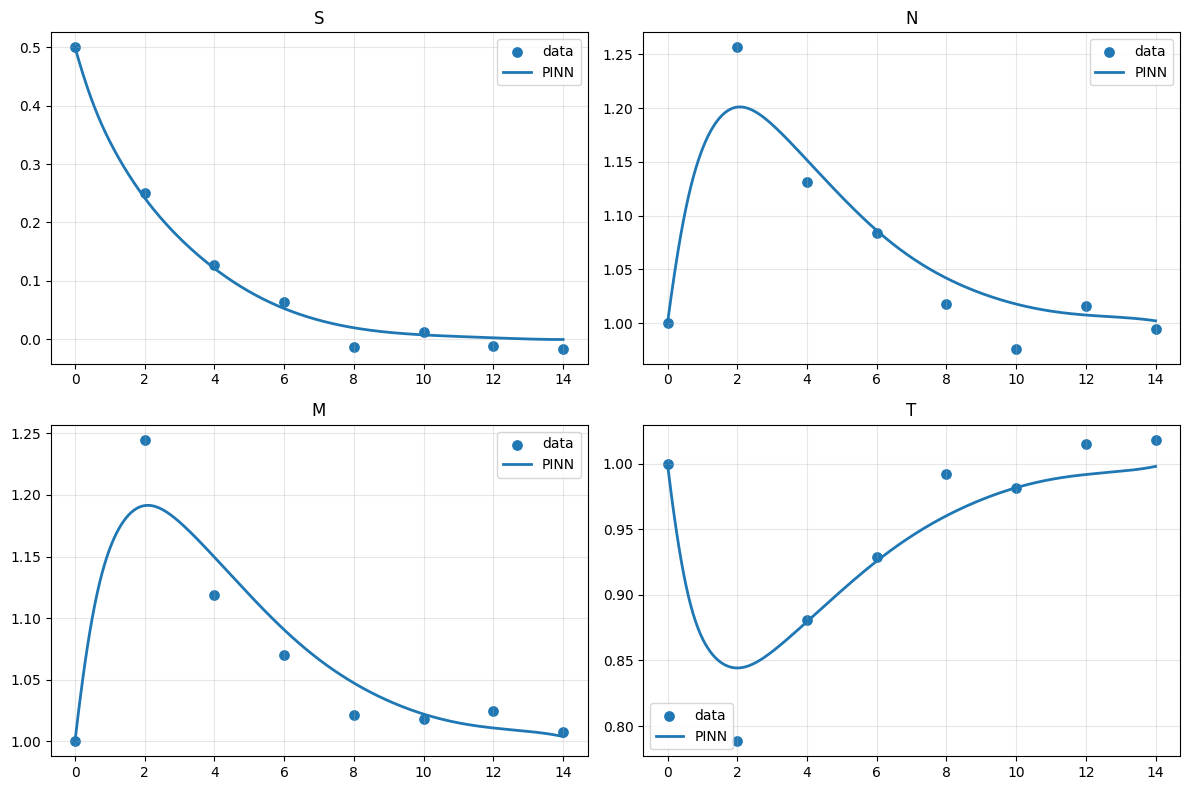

In [41]:
import numpy as np
import torch

import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------
# Data
# ----------------------------
t_data = np.asarray(t_measurements, dtype=np.float64)
y_data = np.asarray(y_measured, dtype=np.float64)

t_min, t_max = t_data.min(), t_data.max()
scale_t = 2.0 / (t_max - t_min)
if t_max == t_min:
    raise ValueError("t_data must span a non-zero time interval.")

# Jacobian of time normalization: tau = norm_t(t)
# dtau/dt = 2/(t_max - t_min) = scale_t
def norm_t(t):
    return 2.0 * (t - t_min) / (t_max - t_min) - 1.0
# on se ramène à l'intervalle [-1, 1] pour la normalisation des entrées du réseau de neurones
t_obs = torch.tensor(norm_t(t_data)[:, None], dtype=torch.float64)
y_obs = torch.tensor(y_data, dtype=torch.float64)

t_col = torch.linspace(t_min, t_max, 300, dtype=torch.float64)[:, None]
t_col_n = torch.tensor(norm_t(t_col.numpy()), dtype=torch.float64, requires_grad=True)

y0_obs = y_obs[0:1]
# Contrainte forte sur la CI : y(t0) = y0 exactement
t0_n = t_obs[:1].detach().clone()      # temps initial normalisé (shape: [1,1])
y0_target = y0_obs.detach().clone()    # condition initiale observée (shape: [1,4])

_Seq = nn.Sequential

class ICConstrainedSequential(_Seq):
    def forward(self, t):
        raw = super().forward(t)  # sortie libre du réseau
        dt = t - t0_n.to(dtype=t.dtype, device=t.device)
        return y0_target.to(dtype=raw.dtype, device=raw.device) + dt * raw

# Le PINN défini plus bas utilisera automatiquement cette version
nn.Sequential = ICConstrainedSequential

# ----------------------------
# PINN model
# ----------------------------
class PINN(nn.Module):
    def __init__(self, width=64, depth=3):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 4)]
        self.net = nn.Sequential(*layers)

        base_params = torch.tensor(params, dtype=torch.float64)  # (alpha, beta, gamma, delta_N, delta_M, a, b)
        self.log_params = nn.Parameter(torch.log(base_params + 1e-6))

    def forward(self, t):
        return self.net(t)

    def get_params(self):
        p = torch.nn.functional.softplus(self.log_params) + 1e-6
        alpha, beta, gamma, delta_N, delta_M, a, b = p
        return alpha, beta, gamma, delta_N, delta_M, a, b

model = PINN().double()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------
# Physics residuals
# ----------------------------
def time_derivative(y, t):
    grads = []
    for i in range(y.shape[1]):
        dy_dtau = torch.autograd.grad(
            y[:, i].sum(), t, create_graph=True, retain_graph=True
        )[0]
        dy_dt = dy_dtau * scale_t
        grads.append(dy_dt)
    return torch.cat(grads, dim=1)

# ----------------------------
# Training
# ----------------------------
n_epochs = 6000
# Weights for loss components: data loss, physics loss, initial condition loss
w_data, w_phys, w_ic = 1.0, 10.0, 20.0

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Data loss
    y_pred = model(t_obs)
    loss_data = torch.mean((y_pred - y_obs) ** 2)

    # Physics loss
    y_col = model(t_col_n)
    dydt = time_derivative(y_col, t_col_n)

    S, N, M, T = [y_col[:, i:i+1] for i in range(4)]
    dS, dN, dM, dT = [dydt[:, i:i+1] for i in range(4)]

    alpha, beta, gamma, delta_N, delta_M, a, b = model.get_params()

    rS = dS - S * (a * N - b * T)
    rN = dN - (alpha * S * N + delta_N * N * (1.0 - N))
    rM = dM - (beta * S + delta_M * M * (1.0 - M))
    rT = dT - (-gamma * S * T + delta_M * M * (1.0 - T))

    loss_phys = torch.mean(rS**2 + rN**2 + rM**2 + rT**2)

    # Initial condition loss
    y0_pred = model(t_obs[:1])
    loss_ic = torch.mean((y0_pred - y0_obs) ** 2)

    loss = w_data * loss_data + w_phys * loss_phys + w_ic * loss_ic
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0 or epoch == n_epochs - 1:
        alpha_, beta_, gamma_, deltaN_, deltaM_, a_, b_ = [
            p.detach().cpu().item() for p in model.get_params()
        ]
        print(
            f"epoch={epoch:5d} loss={loss.item():.3e} "
            f"a={a_:.4f} b={b_:.4f} alpha={alpha_:.4f} beta={beta_:.4f} "
            f"gamma={gamma_:.4f} dN={deltaN_:.4f} dM={deltaM_:.4f}"
        )

# ----------------------------
# Results
# ----------------------------
with torch.no_grad():
    t_plot = torch.linspace(t_min, t_max, 400, dtype=torch.float64)[:, None]
    y_plot = model(torch.tensor(norm_t(t_plot.numpy()), dtype=torch.float64)).cpu().numpy()

params_tensor = torch.stack(model.get_params())
a_hat, b_hat, alpha_hat, beta_hat, gamma_hat, deltaN_hat, deltaM_hat = (
    params_tensor.detach().cpu().numpy()
)

print("\nEstimated parameters:")
print(f"  a       = {a_hat:.6f}")
print(f"  b       = {b_hat:.6f}")
print(f"  alpha   = {alpha_hat:.6f}")
print(f"  beta    = {beta_hat:.6f}")
print(f"  gamma   = {gamma_hat:.6f}")
print(f"  delta_N = {deltaN_hat:.6f}")
print(f"  delta_M = {deltaM_hat:.6f}")

# Plot fit
labels = ["S", "N", "M", "T"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, ax in enumerate(axes):
    ax.scatter(t_data, y_data[:, i], s=45, label="data")
    ax.plot(t_plot.numpy().ravel(), y_plot[:, i], lw=2, label="PINN")
    ax.set_title(labels[i])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [43]:
print(loss_ic.item(), loss_data.item(), loss_phys.item())

0.0 0.0005586704062507425 1.4257674199696147e-05
